In [33]:
import sys
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr

try:
    get_ipython()  # noqa: F821
    _IN_IPYTHON = True
except NameError:
    _IN_IPYTHON = False

import matplotlib
if not _IN_IPYTHON:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.stats import linregress

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    project_root = Path(__file__).resolve().parent.parent
except NameError:
    project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

py_dir = project_root / "py"
nb_dir = project_root / "notebooks"
for p in (str(project_root), str(py_dir), str(nb_dir)):
    if p not in sys.path:
        sys.path.insert(0, p)

import aerocom_data
import cameo_toolbox as ct
import notebook_setup as setup
from aerocom_data import _get_dataarray, _align_da_to_ref
import PPE_set as ppe_cfg
# import AAOD_error_attribution_PPE
print(f"Project root: {project_root}")

Project root: /gpfs/home4/jzhang1/AeroCom_Error


In [24]:
PPE_DIR = project_root / "Data" / "PPE_processed_monthly"
SPEXONE_GLOB = str(
    project_root / "Data" / "SPEXone_regridded" / "SPEXone_L2_regridded_{year}_{month:02d}_v4_0.parquet"
)
SPEXONE_YEARS_MONTHS = [(2024, m) for m in range(8, 13)] + [(2025, m) for m in range(1, 8)]
WVL = "550nm"

EXCLUDE_MEMBERS: List[str] = []
DERIVED_VAR_AFTER_AGG = {
    "lifetime_BC_OA", "lifetime", "lifetime_prim", "lifetime_SO4", "lifetime_S", "lifetime_naive",
}
USE_DEPOSITION_FOR_LIFETIME = False  # depbc/depoa absent from PPE

# PPE burden_* labeled kg m-2 but ~1000× low vs AeroCom; same fix as AOD_SS_ERROR_PPE.
BURDEN_MASS_SCALE = 1e3

MAC_X_COL = "1-SSA"  # theory: MAC = A*(1-SSA)
INTERCEPT_0 = True

BROWN_SSA_INTERCEPT = 0.969
BROWN_SSA_SLOPE = -0.779

SAVE_FIG = False  # True: save to FIGURE_DIR; False: display inline
FIGURE_DIR = project_root / "figure" / "PPE_AAOD"
TABLE_DIR = project_root / "Data" / "PPE_AAOD"
_SCRATCH_CANDIDATES = [
    Path("/scratch-shared/jzhang1/PPE_AAOD"),
    project_root / "Data" / "PPE_AAOD" / "scratch",
]
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
SCRATCH_DIR = None
for _cand in _SCRATCH_CANDIDATES:
    try:
        _cand.mkdir(parents=True, exist_ok=True)
        SCRATCH_DIR = _cand
        break
    except OSError as _e:
        print(f"  Scratch unavailable {_cand}: {_e}")
if SCRATCH_DIR is None:
    raise RuntimeError("Could not create any scratch directory")
print(f"  Using SCRATCH_DIR = {SCRATCH_DIR}")

AXIS_LABELS = {
    "SSA": "SSA (-)",
    "1-SSA": "1 − SSA (-)",
    "MAC": r"MAC (m$^{2}$ g$^{-1}$)",
    "AE": "AE440-550 (-)",
    "precip": r"Model precipitation (mm day$^{-1}$)",
    "rBC": "rBC = BC/(BC+OA) (-)",
    "lifetime_BC_OA": r"BC+OA lifetime $\tau$ (day)",
    "inv_lifetime_BC_OA": r"1/$\tau_{\mathrm{BC+OA}}$ (day$^{-1}$)",
    "abs550aer": "AAOD$_{550}$ (1)",
    "od550aer": "AOD$_{550}$ (1)",
    "load_BC_OA": r"BC+OA burden (kg m$^{-2}$)",
    "emi_BC_OA": r"BC+OA emission (kg m$^{-2}$ s$^{-1}$)",
    "lifetime": r"Total aerosol lifetime $\tau$ (day)",
    "inv_lifetime": r"1/$\tau_{\mathrm{total}}$ (day$^{-1}$)",
    "lifetime_prim": r"Primary aerosol lifetime $\tau$ (day)",
    "inv_lifetime_prim": r"1/$\tau_{\mathrm{prim}}$ (day$^{-1}$)",
    "lifetime_SO4": r"SO$_4$ lifetime $\tau$ (day)",
    "inv_lifetime_SO4": r"1/$\tau_{\mathrm{SO4}}$ (day$^{-1}$)",
    "lifetime_S": r"Sulfur-family lifetime $\tau$ (day)",
    "inv_lifetime_S": r"1/$\tau_{\mathrm{S}}$ (day$^{-1}$)",
    "load_total": r"Total aerosol burden (kg m$^{-2}$)",
    "emi_total": r"Total aerosol source, SO$_4$-eq. (kg m$^{-2}$ s$^{-1}$)",
    "precip_obs": r"GPCP precipitation (mm day$^{-1}$)",
}

SAVE_AGG_CACHE = False
AGG_PARQUET = TABLE_DIR / "aaod_ppe_seasonal_africa_amazon_outflow.parquet"
MONTHLY_PARQUET = TABLE_DIR / "aaod_ppe_monthly_africa_amazon_outflow.parquet"
USE_AGG_CACHE = True

SPEXONE_HOMOGENIZE = True
SSA_SPEXONE_HOMOGENIZE = True
AAOD_SPEXONE_HOMOGENIZE = True

QUALITY_FILTER_PARAMS = {
    "min_aod": 0.01,
    "min_aaod": 1e-5,
    "max_aaod_fraction": 0.95,
    "min_ssa": 0.5,
    "max_ssa": 1.02,
}

# Fire-season boxes from notebook_setup.REGIONS; month-of-year keeps the
# AeroCom seasons while the PPE archive spans Aug 2024 – Jul 2025.
PPE_TIME = ("2024-08-01", "2025-07-31")
REGIONS = {
    "africa": {
        "surface_type": "land",
        "lon_range": (15, 37),
        "lat_range": (-15, 0),
        "time_slice": PPE_TIME,
        "season_months": (6, 7, 8, 9),  # Jun–Sep
        "edge_weighted": False,
    },
    "amazon": {
        "surface_type": "land",
        "lon_range": (287, 317),
        "lat_range": (-17, -3),
        "time_slice": PPE_TIME,
        "season_months": (7, 8, 9, 10),  # Jul–Oct
        "edge_weighted": False,
    },
    "outflow_af": {
        "surface_type": "ocean",
        "lon_range": (350, 15),
        "lat_range": (-15, 0),
        "time_slice": PPE_TIME,
        "season_months": (6, 7, 8, 9),
        "edge_weighted": True,
    },
}
SOURCE_REGIONS = ["africa", "amazon"]
# As in AAOD_error_attribution.ipynb: the outflow box has no local fire emission,
# so no load/emission lifetime there; its AAOD is predicted from African source
# E, tau, MAC with the Zhong et al. (2022) Eq. 6 meta-model.
OUTFLOW_REGION = "outflow_af"
OUTFLOW_SOURCE = "africa"
ANALYSIS_REGIONS = SOURCE_REGIONS + [OUTFLOW_REGION]
PLOT_REGIONS = list(ANALYSIS_REGIONS)
LIFETIME_REGIONS = list(SOURCE_REGIONS)

REGION_COLORS = {
    "africa": "#d62728",
    "amazon": "#2ca02c",
    "outflow_af": "#1f77b4",
}

BC_OA_LOAD = ["loadbc", "loadoa"]
BC_OA_EMI = ["emibc", "emioa"]

PRIM_LOAD = ["loadbc", "loadoa", "loaddust", "loadss"]
PRIM_EMI = ["emibc", "emioa", "emidust", "emiss"]
AER_LOAD = PRIM_LOAD + ["loadso4"]
GAS_LOAD = ["burden_SO2", "burden_DMS"]
LOAD_VARS = AER_LOAD + GAS_LOAD
EMI_VARS = PRIM_EMI + ["emi_SO4", "emiso2", "emi_DMS"]
# Only aerosol burdens carry the ~1000x deficit; the gas burdens give realistic
# global SO2/DMS burdens (~0.8 / ~0.15 Tg, tau ~3 / ~1 d) without scaling.
LOAD_SCALE_VARS = list(AER_LOAD)

# Sulfur emissions/burdens are full-molecule mass (global emiso2 ~99 Tg SO2/yr,
# emi_DMS ~49 Tg DMS/yr), so convert by molar mass.
M_S, M_SO2, M_SO4, M_DMS = 32.06, 64.07, 96.06, 62.13
# Fraction of emitted SO2/DMS sulfur that ends up as sulfate. Without SO4
# production or deposition diagnostics this cannot be diagnosed; 1.0 is the
# upper bound on production and so gives a lower bound on sulfate lifetime.
SO2_TO_SO4_FRAC = 0.5

# Lifetime definitions: name -> (burden weights, emission weights, label)
LIFETIME_DEFS = {
    "lifetime_BC_OA": (
        {"loadbc": 1.0, "loadoa": 1.0},
        {"emibc": 1.0, "emioa": 1.0},
        "BC+OA",
    ),
    "lifetime_prim": (
        {v: 1.0 for v in PRIM_LOAD},
        {v: 1.0 for v in PRIM_EMI},
        "primary aerosol (BC+OA+DU+SS)",
    ),
    # Recommended total: aerosol burden over primary emission + sulfate-equivalent
    # source from SO2/DMS (SO4 is mostly secondary).
    "lifetime": (
        {v: 1.0 for v in AER_LOAD},
        {
            **{v: 1.0 for v in PRIM_EMI},
            "emi_SO4": 1.0,
            "emiso2": SO2_TO_SO4_FRAC * M_SO4 / M_SO2,
            "emi_DMS": SO2_TO_SO4_FRAC * M_SO4 / M_DMS,
        },
        "total aerosol (SO4-eq. source)",
    ),
    "lifetime_SO4": (
        {"loadso4": 1.0},
        {
            "emi_SO4": 1.0,
            "emiso2": SO2_TO_SO4_FRAC * M_SO4 / M_SO2,
            "emi_DMS": SO2_TO_SO4_FRAC * M_SO4 / M_DMS,
        },
        "SO4 (SO4-eq. source)",
    ),
    # Closed sulfur-family budget in S mass (gas + aerosol burdens).
    "lifetime_S": (
        {"loadso4": M_S / M_SO4, "burden_SO2": M_S / M_SO2, "burden_DMS": M_S / M_DMS},
        {"emi_SO4": M_S / M_SO4, "emiso2": M_S / M_SO2, "emi_DMS": M_S / M_DMS},
        "sulfur family (S mass)",
    ),
    # Diagnostic only: plain mass sum of all species incl. gases.
    "lifetime_naive": (
        {v: 1.0 for v in LOAD_VARS},
        {v: 1.0 for v in EMI_VARS},
        "naive mass sum (diagnostic)",
    ),
}
LIFETIME_COLS = list(LIFETIME_DEFS)

VARIABLES_NEEDED = [
    "od440aer", "od550aer", "abs550aer",
    "precip",
] + LOAD_VARS + EMI_VARS


def ens_label(ens_id: int) -> str:
    eid = int(ens_id)
    return "Control" if eid < 0 else str(eid)


def finish_fig(fig, name: str, save_fig: bool = None) -> Path:
    if save_fig is None:
        save_fig = SAVE_FIG
    path = FIGURE_DIR / name
    if save_fig:
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
        plt.close(fig)
    else:
        plt.show()
    return path


def _axis_label(col: str, override=None) -> str:
    if override:
        return override
    return AXIS_LABELS.get(col, col)


print("--- Active configuration ---")
print(f"  PPE_DIR              = {PPE_DIR}")
print(f"  ANALYSIS_REGIONS     = {ANALYSIS_REGIONS}")
print(f"  DERIVED_VAR_AFTER_AGG= {DERIVED_VAR_AFTER_AGG}")
print(f"  BURDEN_MASS_SCALE    = {BURDEN_MASS_SCALE}")
print(f"  MAC_X_COL            = {MAC_X_COL!r}  INTERCEPT_0={INTERCEPT_0}")
print(f"  USE_DEPOSITION_FOR_LIFETIME = {USE_DEPOSITION_FOR_LIFETIME}")
print(f"  FIGURE_DIR           = {FIGURE_DIR}")
print(f"  TABLE_DIR            = {TABLE_DIR}")
print(f"  SCRATCH_DIR          = {SCRATCH_DIR}")

# Runtime gap tracker (written to potential_issues.md at the end)
ISSUES: List[str] = []


  Using SCRATCH_DIR = /scratch-shared/jzhang1/PPE_AAOD
--- Active configuration ---
  PPE_DIR              = /gpfs/home4/jzhang1/AeroCom_Error/Data/PPE_processed_monthly
  ANALYSIS_REGIONS     = ['africa', 'amazon', 'outflow_af']
  DERIVED_VAR_AFTER_AGG= {'lifetime_naive', 'lifetime', 'lifetime_S', 'lifetime_prim', 'lifetime_SO4', 'lifetime_BC_OA'}
  BURDEN_MASS_SCALE    = 1000.0
  MAC_X_COL            = '1-SSA'  INTERCEPT_0=True
  USE_DEPOSITION_FOR_LIFETIME = False
  FIGURE_DIR           = /gpfs/home4/jzhang1/AeroCom_Error/figure/PPE_AAOD
  TABLE_DIR            = /gpfs/home4/jzhang1/AeroCom_Error/Data/PPE_AAOD
  SCRATCH_DIR          = /scratch-shared/jzhang1/PPE_AAOD


# Load PPE monthly ensemble NetCDFs (reuse existing extract)

In [25]:

GROUP_FILES = {
    "burden": PPE_DIR / "burden_monthly.nc",
    "emi": PPE_DIR / "emi_monthly.nc",
    "optical": PPE_DIR / "optical_monthly.nc",
    "precip": PPE_DIR / "precip_monthly.nc",
}


def load_ppe_as_model_dict(ppe_files: Dict[str, Path]) -> Tuple[Dict[str, Dict[str, xr.Dataset]], List[str]]:
    for key, path in ppe_files.items():
        if not path.is_file():
            raise FileNotFoundError(f"Missing PPE group file ({key}): {path}")

    opened = {k: xr.open_dataset(p) for k, p in ppe_files.items()}
    try:
        ens_ids = [int(e) for e in opened["burden"].ens.values]
        labels = [ens_label(e) for e in ens_ids]
        if EXCLUDE_MEMBERS:
            keep = [
                (e, lab) for e, lab in zip(ens_ids, labels)
                if lab not in EXCLUDE_MEMBERS and str(e) not in EXCLUDE_MEMBERS
            ]
            ens_ids, labels = (list(x) for x in zip(*keep)) if keep else ([], [])

        data: Dict[str, Dict[str, xr.Dataset]] = {lab: {} for lab in labels}
        for lab, eid in zip(labels, ens_ids):
            for group_ds in opened.values():
                sub = group_ds.sel(ens=eid)
                for var in sub.data_vars:
                    if var == "experiment":
                        continue
                    da = sub[var]
                    if "ens" in da.dims:
                        da = da.squeeze("ens", drop=True)
                    elif "ens" in da.coords:
                        da = da.drop_vars("ens")
                    if "experiment" in da.coords:
                        da = da.drop_vars("experiment")
                    data[lab][var] = da.to_dataset(name=var)
        return data, labels
    finally:
        for ds in opened.values():
            ds.close()


if USE_AGG_CACHE and AGG_PARQUET.is_file():
    print("USE_AGG_CACHE=True: skipping NetCDF load")
    raw_data: Dict = {}
    models: List[str] = []
else:
    print(f"Loading PPE monthly ensembles from {PPE_DIR} ...")
    raw_data, models = load_ppe_as_model_dict(GROUP_FILES)
    print(f"Ensemble members: {len(models)}")
    if models:
        print(f"  first={models[0]}  last={models[-1]}")

USE_AGG_CACHE=True: skipping NetCDF load


In [26]:
def apply_aerosol_quality_filter(
    aod, aaod=None, ssa=None,
    min_aod=0.01, min_aaod=1e-5,
    max_aaod_fraction=0.95,
    min_ssa=0.5, max_ssa=1.02,
):
    def _where(var, cond):
        if var is None:
            return None
        if hasattr(var, "where"):
            return var.where(cond)
        out = var.copy()
        out[~np.asarray(cond)] = np.nan
        return out

    aod_mask = (aod > min_aod) & np.isfinite(aod)
    abs_mask = aod_mask
    if aaod is not None:
        abs_mask = (
            abs_mask
            & (aaod > min_aaod)
            & (aaod < aod * max_aaod_fraction)
            & np.isfinite(aaod)
        )
    if ssa is not None:
        abs_mask = abs_mask & (ssa >= min_ssa) & (ssa <= max_ssa) & np.isfinite(ssa)

    aod_out = _where(aod, aod_mask)
    aaod_out = _where(aaod, abs_mask)
    ssa_out = _where(ssa, abs_mask)
    if ssa_out is not None:
        ssa_out = ssa_out.clip(0.0, 1.0)
    return aod_out, aaod_out, ssa_out


# "lt" infix keeps sums from clobbering raw streams (e.g. emi_SO4).
def _lt_load_key(lt_name: str) -> str:
    return {"lifetime_BC_OA": "load_BC_OA", "lifetime": "load_total"}.get(
        lt_name, lt_name.replace("lifetime", "load_lt")
    )


def _lt_emi_key(lt_name: str) -> str:
    return {"lifetime_BC_OA": "emi_BC_OA", "lifetime": "emi_total"}.get(
        lt_name, lt_name.replace("lifetime", "emi_lt")
    )


def weighted_sum_datasets(model_data, weights: Dict[str, float], out_name: str):
    """sum_i w_i * var_i; None unless every component is present (require_all)."""
    if any(model_data.get(k) is None for k in weights):
        return None
    total = None
    for key, w in weights.items():
        da = _get_dataarray(model_data[key], key) * float(w)
        total = da if total is None else total + da
    return total.to_dataset(name=out_name)


if USE_AGG_CACHE and AGG_PARQUET.is_file():
    print("USE_AGG_CACHE=True: skipping normalize/sums")
    data: Dict = {}
    target_models: List[str] = []
else:
    data = {}
    for m in models:
        normalized = {}
        for var in VARIABLES_NEEDED:
            if raw_data[m].get(var) is None:
                continue
            try:
                normalized[var] = setup.normalize_dataset_time(
                    raw_data[m][var], var_hint=f"{m}/{var}"
                )
            except Exception as e:
                print(f"  Failed to normalize {m}/{var}: {e}")
                normalized[var] = raw_data[m][var]

        if BURDEN_MASS_SCALE != 1.0:
            for key in LOAD_SCALE_VARS:
                ds = normalized.get(key)
                if ds is None:
                    continue
                da = _get_dataarray(ds, key)
                if da is None:
                    continue
                da = da * BURDEN_MASS_SCALE
                da.attrs["units"] = "kg m-2"
                da.attrs["burden_mass_scale"] = float(BURDEN_MASS_SCALE)
                normalized[key] = da.to_dataset(name=key)

        normalized["load_BC_OA"] = setup.sum_datasets(
            normalized, BC_OA_LOAD, "load_BC_OA", require_all=True
        )
        normalized["emi_BC_OA"] = setup.sum_datasets(
            normalized, BC_OA_EMI, "emi_BC_OA", require_all=True
        )
        for lt_name, (load_w, emi_w, _) in LIFETIME_DEFS.items():
            if lt_name == "lifetime_BC_OA":
                continue
            normalized[_lt_load_key(lt_name)] = weighted_sum_datasets(
                normalized, load_w, _lt_load_key(lt_name)
            )
            normalized[_lt_emi_key(lt_name)] = weighted_sum_datasets(
                normalized, emi_w, _lt_emi_key(lt_name)
            )
        data[m] = normalized

    target_models = [
        m for m in models
        if data[m].get("od550aer") is not None
        and data[m].get("abs550aer") is not None
        and data[m].get("load_BC_OA") is not None
        and data[m].get("emi_BC_OA") is not None
    ]
    print(f"Target members with od550aer+abs550aer+load_BC_OA+emi_BC_OA: {len(target_models)}")
    for lt_name in LIFETIME_COLS:
        lk, ek = _lt_load_key(lt_name), _lt_emi_key(lt_name)
        n_ok = sum(
            1 for m in target_models
            if data[m].get(lk) is not None and data[m].get(ek) is not None
        )
        print(f"  {lk}/{ek} available: {n_ok}/{len(target_models)}")
        if n_ok < len(target_models):
            ISSUES.append(
                f"{lk}/{ek} missing for {len(target_models) - n_ok} members (require_all)."
            )
    if target_models and BURDEN_MASS_SCALE != 1.0:
        print(f"Applied BURDEN_MASS_SCALE={BURDEN_MASS_SCALE} to {LOAD_SCALE_VARS}")

raw_data = None

USE_AGG_CACHE=True: skipping normalize/sums


# Pre-aggregation derived variables (MAC, SSA, AE, rBC)

In [27]:
if USE_AGG_CACHE and AGG_PARQUET.is_file():
    print("USE_AGG_CACHE=True: skipping derived vars")
    data_derived: Dict = {}
else:
    derived_vars_pre = [
        dv for dv in ["MAC", "SSA", "AE", "rBC"]
        if dv not in DERIVED_VAR_AFTER_AGG
    ]
    derived = {m: {} for m in target_models}

    for m in target_models:
        aerocom_data.align_model_grids(data[m], ref_var="od550aer", model_hint=m)
    print(f"Grid-aligned {len(target_models)} members onto od550aer.")

    for m in target_models:
        model_data = data[m]
        aod550 = _get_dataarray(model_data.get("od550aer"), "od550aer")
        if aod550 is None:
            continue
        aaod = _get_dataarray(model_data.get("abs550aer"), "abs550aer")
        if aaod is not None:
            aaod = _align_da_to_ref(aaod, aod550, model_hint=f"{m}/abs550aer")
            aod550_f, aaod_f, ssa = apply_aerosol_quality_filter(
                aod=aod550, aaod=aaod, ssa=1.0 - aaod / aod550,
                **QUALITY_FILTER_PARAMS,
            )
            aod550 = aod550_f
            aaod = aaod_f
        else:
            ssa = None

        load_bc = _get_dataarray(model_data.get("loadbc"), "loadbc")
        load_oa = _get_dataarray(model_data.get("loadoa"), "loadoa")
        load_bcoa = _get_dataarray(model_data.get("load_BC_OA"), "load_BC_OA")

        for dv in derived_vars_pre:
            try:
                if dv == "SSA":
                    if ssa is None:
                        raise KeyError("Missing abs550aer for SSA.")
                    derived[m]["SSA"] = ssa
                elif dv == "MAC":
                    if aaod is None or load_bcoa is None:
                        raise KeyError("Missing abs550aer or load_BC_OA for MAC.")
                    load_a = _align_da_to_ref(load_bcoa, aod550, model_hint=f"{m}/load_BC_OA")
                    # MAC = AAOD / (load_BC_OA * 1e3)  → m² g⁻¹
                    derived[m]["MAC"] = aaod / (load_a * 1e3)
                elif dv == "rBC":
                    if load_bc is None or load_oa is None:
                        raise KeyError("Missing loadbc/loadoa for rBC.")
                    bc_a = _align_da_to_ref(load_bc, aod550, model_hint=f"{m}/loadbc")
                    oa_a = _align_da_to_ref(load_oa, aod550, model_hint=f"{m}/loadoa")
                    denom = bc_a + oa_a
                    derived[m]["rBC"] = (bc_a / denom).where(denom > 0)
                elif dv == "AE":
                    aod440 = _get_dataarray(model_data.get("od440aer"), "od440aer")
                    if aod440 is None:
                        raise KeyError("Missing od440aer for AE440-550.")
                    aod440 = _align_da_to_ref(aod440, aod550, model_hint=f"{m}/od440aer")
                    aod440 = aod440.where(np.isfinite(aod550))
                    derived[m]["AE"] = -np.log(aod550 / aod440) / np.log(550.0 / 440.0)
            except Exception as e:
                print(f"  Derived {dv} failed for {m}: {e}")
                derived[m][dv] = None

    data_derived = {}
    for m in target_models:
        data_derived[m] = dict(data[m])
        for dv, val in derived[m].items():
            if val is None:
                data_derived[m][dv] = None
            elif isinstance(val, xr.Dataset):
                data_derived[m][dv] = val
            else:
                data_derived[m][dv] = val.to_dataset(name=dv)

# %%
# -----------------------------------------------------------------------------
# Regional aggregation (monthly over PPE year; seasonal via season_months)
# -----------------------------------------------------------------------------
def _as_da_dict(model_dict, var_name):
    out = {}
    for model, md in model_dict.items():
        if var_name not in md or md[var_name] is None:
            continue
        val = md[var_name]
        if isinstance(val, xr.Dataset):
            val = _get_dataarray(val, var_name)
        out[model] = {var_name: val}
    return out


def _month_number(val) -> Optional[int]:
    if val is None or (isinstance(val, float) and not np.isfinite(val)):
        return None
    if isinstance(val, pd.Period):
        return int(val.month)
    if hasattr(val, "month"):
        try:
            return int(val.month)
        except Exception:
            pass
    try:
        ts = pd.Timestamp(val)
        if pd.notna(ts):
            return int(ts.month)
    except Exception:
        pass
    try:
        return int(val)
    except Exception:
        return None


def seasonal_from_monthly(monthly_df: pd.DataFrame) -> pd.DataFrame:
    """Mean over season_months per region/model (handles year-boundary seasons)."""
    if monthly_df.empty:
        return monthly_df.copy()
    work = monthly_df.copy()
    work["_mon"] = work["month"].map(_month_number)
    rows = []
    value_cols = [
        c for c in work.columns
        if c not in ("region", "model", "month", "_mon")
    ]
    for region in ANALYSIS_REGIONS:
        months = set(REGIONS[region]["season_months"])
        sub = work.loc[(work["region"] == region) & (work["_mon"].isin(months))]
        if sub.empty:
            continue
        for model, g in sub.groupby("model"):
            row = {"region": region, "model": model}
            for c in value_cols:
                row[c] = pd.to_numeric(g[c], errors="coerce").mean()
            rows.append(row)
    return pd.DataFrame(rows)


if USE_AGG_CACHE and AGG_PARQUET.is_file():
    print("USE_AGG_CACHE=True: skipping regional aggregation")
    model_monthly = {}
    model_seasonal = {}
    masks = {}
    model_monthly_df = (
        pd.read_parquet(MONTHLY_PARQUET) if MONTHLY_PARQUET.is_file() else pd.DataFrame()
    )
    model_seasonal_df = pd.read_parquet(AGG_PARQUET)
else:
    template = data[target_models[0]]["od550aer"].isel(time=0)
    masks = setup.create_analysis_masks(
        template, ANALYSIS_REGIONS, region=REGIONS, surface_type=None
    )
    print("Regions created:", list(masks.keys()))

    variables_pre_aggregated = [
        "MAC", "SSA", "AE", "rBC",
        "precip",
        *[k for lt in LIFETIME_COLS for k in (_lt_load_key(lt), _lt_emi_key(lt))],
        "od550aer", "abs550aer", "loadbc", "loadoa", "emibc", "emioa",
    ]
    variables_to_aggregate = [
        v for v in variables_pre_aggregated if v not in DERIVED_VAR_AFTER_AGG
    ]

    model_monthly = {}
    for region in ANALYSIS_REGIONS:
        model_monthly[region] = {}
        for var in variables_to_aggregate:
            model_monthly[region][var] = setup.aggregate_region(
                _as_da_dict(data_derived, var),
                var,
                region,
                masks,
                region=REGIONS,
                return_time_series=True,
                skipna=True,
            )

    # Placeholder seasonal dict (rebuilt from monthly after lifetime)
    model_seasonal = {r: {} for r in ANALYSIS_REGIONS}

    model_monthly_df, _ = setup.convert_aggregation_to_dataframes(
        model_monthly, model_seasonal, month_col="month"
    )
    model_seasonal_df = seasonal_from_monthly(model_monthly_df)

    # Post-aggregation emission lifetimes on seasonal means (all LIFETIME_DEFS)
    LIFETIME_SPECS = {lt: (_lt_load_key(lt), _lt_emi_key(lt)) for lt in LIFETIME_COLS}
    model_seasonal_df = model_seasonal_df.copy()
    for out_key, (load_key, flux_key) in LIFETIME_SPECS.items():
        model_seasonal_df[out_key] = np.nan
        if load_key not in model_seasonal_df.columns or flux_key not in model_seasonal_df.columns:
            print(f"  Skip {out_key}: missing {load_key} or {flux_key}")
            ISSUES.append(f"{out_key} not computed: {load_key} or {flux_key} missing after aggregation.")
            continue
        for region in LIFETIME_REGIONS:
            mask = model_seasonal_df["region"] == region
            sub = model_seasonal_df.loc[mask]
            load = {
                str(m): float(v)
                for m, v in zip(sub["model"], sub[load_key])
                if np.isfinite(v)
            }
            flux = {
                str(m): float(v)
                for m, v in zip(sub["model"], sub[flux_key])
                if np.isfinite(v)
            }
            lt = setup._lifetime_from_load_flux(load, flux, out_key, region)
            model_seasonal[region][out_key] = lt
            model_seasonal_df.loc[mask, out_key] = (
                model_seasonal_df.loc[mask, "model"].astype(str).map(lt).to_numpy()
            )
            print(f"  seasonal/{region}: {out_key}={len(lt)}")

        # Monthly lifetimes for completeness
        if load_key in model_monthly_df.columns and flux_key in model_monthly_df.columns:
            with np.errstate(divide="ignore", invalid="ignore"):
                model_monthly_df[out_key] = model_monthly_df[load_key] / (
                    model_monthly_df[flux_key] * 86400.0
                )
            model_monthly_df.loc[
                ~model_monthly_df["region"].isin(LIFETIME_REGIONS), out_key
            ] = np.nan

    if SAVE_AGG_CACHE:
        scratch_monthly = SCRATCH_DIR / MONTHLY_PARQUET.name
        scratch_seasonal = SCRATCH_DIR / AGG_PARQUET.name
        model_monthly_df.to_parquet(scratch_monthly)
        model_seasonal_df.to_parquet(scratch_seasonal)
        model_monthly_df.to_parquet(MONTHLY_PARQUET)
        model_seasonal_df.to_parquet(AGG_PARQUET)
        print(f"Wrote scratch {scratch_monthly}")
        print(f"Wrote scratch {scratch_seasonal}")
        print(f"Wrote {MONTHLY_PARQUET}")
        print(f"Wrote {AGG_PARQUET}")

print("\nSeasonal availability:")
availability_columns = [
    var for var in ["MAC", "SSA", "AE", "rBC", *LIFETIME_COLS, "precip", "abs550aer"]
    if var in model_seasonal_df.columns
]
if not model_seasonal_df.empty and availability_columns:
    print(model_seasonal_df.groupby("region")[availability_columns].count())
print(model_seasonal_df.head())


USE_AGG_CACHE=True: skipping derived vars
USE_AGG_CACHE=True: skipping regional aggregation

Seasonal availability:
            MAC  SSA   AE  rBC  lifetime_BC_OA  lifetime_prim  lifetime  \
region                                                                    
africa      251  251  251  251             251            251       251   
amazon      251  251  251  251             251            251       251   
outflow_af  251  251  251  251               0              0         0   

            lifetime_SO4  lifetime_S  lifetime_naive  precip  abs550aer  
region                                                                   
africa               251         251             251     251        251  
amazon               251         251             251     251        251  
outflow_af             0           0               0     251        251  
   region model       MAC       SSA        AE       rBC    precip  load_BC_OA  \
0  africa     1  0.511030  0.828224  1.459525  0.198179  

# GPCP observed precipitation (PPE year Aug 2024 – Jul 2025)

In [28]:
GPCP_DIR = project_root / "Data" / "Prec"
GPCP_VAR = "sat_gauge_precip"  # mm day-1
GPCP_FILE = "GPCPMON_L3_{year}{month:02d}_V3.3.nc4"
# Jul 2025 is not in Data/Prec; month-of-year seasons let Jul 2024 stand in.
GPCP_FILL_MONTHS = {(2025, 7): (2024, 7)}


def load_gpcp_ppe_year() -> Tuple[Optional[xr.DataArray], Dict[str, str]]:
    das, source = [], {}
    for year, month in SPEXONE_YEARS_MONTHS:
        src = (year, month)
        path = GPCP_DIR / GPCP_FILE.format(year=year, month=month)
        if not path.is_file() and src in GPCP_FILL_MONTHS:
            src = GPCP_FILL_MONTHS[src]
            path = GPCP_DIR / GPCP_FILE.format(year=src[0], month=src[1])
            if path.is_file():
                print(f"  GPCP {year}-{month:02d} missing -> using {src[0]}-{src[1]:02d}")
                ISSUES.append(
                    f"GPCP {year}-{month:02d} missing in Data/Prec; filled with "
                    f"{src[0]}-{src[1]:02d} (affects month 7 of every fire season)."
                )
        if not path.is_file():
            print(f"  GPCP missing: {path.name}")
            ISSUES.append(f"Missing GPCP file: {path.name}")
            continue
        with xr.open_dataset(path) as ds:
            da = ds[GPCP_VAR].isel(time=0, drop=True).load()
        da = da.assign_coords(lon=(da.lon + 360.0) % 360.0).sortby("lon").sortby("lat")
        das.append(da.expand_dims(time=[pd.Timestamp(year, month, 1)]))
        source[f"{year}-{month:02d}"] = f"{src[0]}-{src[1]:02d}"
    if not das:
        return None, source
    return xr.concat(das, dim="time"), source


def gpcp_region_monthly(da: xr.DataArray, region_name: str) -> pd.Series:
    cfg = REGIONS[region_name]
    lon0, lon1 = cfg["lon_range"]
    lat0, lat1 = cfg["lat_range"]
    if lon0 <= lon1:
        lon_ok = (da.lon >= lon0) & (da.lon <= lon1)
    else:
        lon_ok = (da.lon >= lon0) | (da.lon <= lon1)
    sub = da.sel(lat=slice(lat0, lat1)).where(lon_ok, drop=True)
    ts = sub.weighted(np.cos(np.deg2rad(sub.lat))).mean(("lat", "lon"))
    return ts.to_series()


print("\n--- GPCP ---")
gpcp_da, gpcp_source = load_gpcp_ppe_year()
gpcp_obs: Dict[str, float] = {}
gpcp_rows = []
if gpcp_da is None:
    ISSUES.append("No GPCP files found for the PPE year; observed precip unavailable.")
else:
    for region in ANALYSIS_REGIONS:
        ts = gpcp_region_monthly(gpcp_da, region)
        months = REGIONS[region]["season_months"]
        in_season = ts[ts.index.month.isin(months)]
        gpcp_obs[region] = float(in_season.mean()) if len(in_season) else np.nan
        for t, v in ts.items():
            key = f"{t.year}-{t.month:02d}"
            gpcp_rows.append({
                "region": region, "month": key, "source_month": gpcp_source.get(key),
                "in_season": t.month in months, "precip_obs": float(v),
            })
        print(f"  {region}: GPCP season mean = {gpcp_obs[region]:.3f} mm/day "
              f"(months {months}, n={len(in_season)})")
    pd.DataFrame(gpcp_rows).to_csv(TABLE_DIR / "gpcp_region_monthly.csv", index=False)
    print(f"Wrote {TABLE_DIR / 'gpcp_region_monthly.csv'}")


--- GPCP ---
  GPCP 2025-07 missing -> using 2024-07
  africa: GPCP season mean = 1.148 mm/day (months (6, 7, 8, 9), n=4)
  amazon: GPCP season mean = 1.568 mm/day (months (7, 8, 9, 10), n=4)
  outflow_af: GPCP season mean = 0.293 mm/day (months (6, 7, 8, 9), n=4)
Wrote /gpfs/home4/jzhang1/AeroCom_Error/Data/PPE_AAOD/gpcp_region_monthly.csv


# Functions help 

In [ ]:
def lifetime_range_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in LIFETIME_COLS:
        if col not in df.columns:
            continue
        for region, g in df.groupby("region"):
            s = g[col].replace([np.inf, -np.inf], np.nan).dropna()
            s = s[s > 0]
            if s.empty:
                continue
            q = s.quantile([0.05, 0.5, 0.95])
            rows.append({
                "lifetime": col, "definition": LIFETIME_DEFS[col][2], "region": region,
                "tau_q05_d": q.loc[0.05], "tau_median_d": q.loc[0.5], "tau_q95_d": q.loc[0.95],
                "inv_tau_median_per_d": 1.0 / q.loc[0.5], "n": len(s),
            })
    return pd.DataFrame(rows)


def print_derived_range_check(df: pd.DataFrame) -> None:
    print("\n--- Derived-variable range check (seasonal) ---")
    checks = [("MAC", (0.0, 15.0))] + [(c, None) for c in LIFETIME_COLS]
    for col, expected in checks:
        if col not in df.columns:
            print(f"  {col}: missing")
            ISSUES.append(f"Range check: column {col} missing from seasonal table.")
            continue
        s = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        if s.empty:
            print(f"  {col}: no finite values")
            ISSUES.append(f"Range check: no finite {col} values.")
            continue
        q = s.quantile([0.05, 0.5, 0.95])
        print(
            f"  {col}: median={q.loc[0.5]:.4g}  "
            f"q05={q.loc[0.05]:.4g}  q95={q.loc[0.95]:.4g}  n={len(s)}"
        )
        if col.startswith("lifetime"):
            inv = 1.0 / s[s > 0]
            qi = inv.quantile([0.05, 0.5, 0.95])
            print(
                f"    1/{col}: median={qi.loc[0.5]:.4g}  "
                f"q05={qi.loc[0.05]:.4g}  q95={qi.loc[0.95]:.4g}  "
                f"(expect ~0.1–1 day^-1)"
            )
            if qi.loc[0.5] > 10 or qi.loc[0.5] < 0.01:
                ISSUES.append(
                    f"1/{col} median={qi.loc[0.5]:.4g} outside expected ~0.1–1; "
                    "check BURDEN_MASS_SCALE / emission units."
                )
        elif expected is not None:
            lo, hi = expected
            inside = float(((s >= lo) & (s <= hi)).mean() * 100)
            print(f"    fraction in [{lo}, {hi}]: {inside:.1f}%")
            if inside < 50:
                ISSUES.append(
                    f"{col}: only {inside:.1f}% of values in [{lo}, {hi}] "
                    "(possible unit / burden-scale issue)."
                )


def print_precip_check(df: pd.DataFrame) -> pd.DataFrame:
    print("\n--- Model precip vs GPCP (fire-season mean, mm/day) ---")
    rows = []
    for region in ANALYSIS_REGIONS:
        s = df.loc[df["region"] == region, "precip"].dropna() if "precip" in df else pd.Series(dtype=float)
        obs = gpcp_obs.get(region, np.nan)
        if s.empty:
            continue
        q = s.quantile([0.05, 0.5, 0.95])
        frac_below = float((s < obs).mean() * 100) if np.isfinite(obs) else np.nan
        print(f"  {region}: PPE median={q.loc[0.5]:.3f} [q05={q.loc[0.05]:.3f}, "
              f"q95={q.loc[0.95]:.3f}]  GPCP={obs:.3f}  ({frac_below:.0f}% of members drier)")
        if np.isfinite(obs) and not (s.min() <= obs <= s.max()):
            ISSUES.append(
                f"GPCP precip in {region} ({obs:.3f} mm/day) is outside the PPE range "
                f"[{s.min():.3f}, {s.max():.3f}]; constrained lifetime is an extrapolation."
            )
        rows.append({"region": region, "precip_obs": obs, "ppe_q05": q.loc[0.05],
                     "ppe_median": q.loc[0.5], "ppe_q95": q.loc[0.95],
                     "pct_members_drier": frac_below})
    return pd.DataFrame(rows)


if not model_seasonal_df.empty:
    print_derived_range_check(model_seasonal_df)
    lt_table = lifetime_range_table(model_seasonal_df)
    if not lt_table.empty:
        print("\nLifetime definitions by region (seasonal, days):")
        print(lt_table.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
        lt_table.to_csv(TABLE_DIR / "ppe_lifetime_range_check.csv", index=False)
    precip_check = print_precip_check(model_seasonal_df)
    if not precip_check.empty:
        precip_check.to_csv(TABLE_DIR / "ppe_precip_vs_gpcp.csv", index=False)

# %%
# -----------------------------------------------------------------------------
# Plot helpers (no member labels / legends)
# -----------------------------------------------------------------------------
def plot_mac_vs_x(
    df: pd.DataFrame,
    x_col: str = "SSA",
    force_intercept_zero: bool = False,
    regions=None,
    filename: str = "ppe_MAC_vs_x.png",
    title: str = None,
    save_fig: bool = None,
):
    regions = regions or PLOT_REGIONS
    if df.empty or "MAC" not in df.columns or "SSA" not in df.columns:
        print(f"Skip {filename}: missing MAC/SSA")
        return
    fig, axes = plt.subplots(1, len(regions), figsize=(4.5 * len(regions), 4.2), squeeze=False)
    axes = axes.ravel()
    for ax, region in zip(axes, regions):
        sub = df.loc[df["region"] == region, ["model", "SSA", "MAC"]].copy()
        if x_col == "1-SSA":
            sub[x_col] = 1.0 - sub["SSA"]
        else:
            sub[x_col] = sub["SSA"]
        sub = sub[["model", x_col, "MAC"]].replace([np.inf, -np.inf], np.nan).dropna()
        color = REGION_COLORS.get(region, "#333333")
        if sub.empty:
            ax.set_title(f"{region}: no data")
            continue
        x = sub[x_col].to_numpy(dtype=float)
        y = sub["MAC"].to_numpy(dtype=float)
        ax.scatter(x, y, s=28, alpha=0.65, color=color, edgecolors="k", linewidths=0.3)
        if len(sub) >= 2:
            if force_intercept_zero:
                slope = float(np.nansum(x * y) / np.nansum(x * x)) if np.nansum(x * x) else np.nan
                intercept = 0.0
                r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
            else:
                lr = linregress(x, y)
                slope, intercept, r = lr.slope, lr.intercept, lr.rvalue
            xs = np.linspace(np.nanmin(x), np.nanmax(x), 40)
            ax.plot(xs, slope * xs + intercept, color="k", lw=1.4)
            ax.set_title(f"{region}: y={slope:.2f}x+{intercept:.2f} r={r:.2f} n={len(sub)}")
        else:
            ax.set_title(f"{region}: n={len(sub)}")
        ax.set_xlabel(_axis_label(x_col))
        ax.set_ylabel(_axis_label("MAC"))
        ax.grid(True, alpha=0.3)
    fig.suptitle(title or f"PPE: MAC vs {x_col}")
    fig.tight_layout()
    finish_fig(fig, filename, save_fig=save_fig)


def plot_ssa_vs_rbc(df: pd.DataFrame, TITLE = "PPE: SSA vs rBC" ,regions=None, filename="ppe_SSA_vs_rBC.png", save_fig=None):
    regions = regions or PLOT_REGIONS
    if "rBC" not in df.columns or "SSA" not in df.columns:
        print("Skip SSA vs rBC: missing columns")
        return
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for idx, region in enumerate(regions):
        sub = df.loc[df["region"] == region, ["rBC", "SSA"]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        if sub.empty:
            continue
        ax.scatter(
            sub["rBC"], sub["SSA"], s=28, alpha=0.65,
            color=REGION_COLORS.get(region, f"C{idx}"),
            edgecolors="k", linewidths=0.3, label=region,
        )
    # Brown et al. (2021) line (drawn, not fit)
    xs = np.linspace(0, 0.6, 50)
    ax.plot(
        xs, BROWN_SSA_INTERCEPT + BROWN_SSA_SLOPE * xs,
        "k--", lw=1.5, label="Brown et al. 2021",
    )
    ax.set_xlabel(_axis_label("rBC"))
    ax.set_ylabel(_axis_label("SSA"))
    ax.set_title(TITLE)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    finish_fig(fig, filename, save_fig=save_fig)


def plot_tau_vs_x(
    df, lifetime_col="lifetime_BC_OA", x_var="precip",
    regions=None, filename=None, title=None, save_fig=None,
):
    regions = regions or LIFETIME_REGIONS
    if lifetime_col not in df.columns or x_var not in df.columns:
        print(f"Skip plot_tau_vs_x: missing {lifetime_col} or {x_var}")
        return
    fig, axes = plt.subplots(1, len(regions), figsize=(4.8 * len(regions), 4), squeeze=False)
    axes = axes.ravel()
    for ax, region in zip(axes, regions):
        sub = df.loc[
            df["region"] == region, ["model", x_var, lifetime_col]
        ].replace([np.inf, -np.inf], np.nan).dropna()
        sub = sub.loc[sub[lifetime_col] > 0]
        color = REGION_COLORS.get(region, "#333333")
        if sub.empty:
            ax.set_title(f"{region}: no data")
            continue
        y = 1.0 / sub[lifetime_col].to_numpy(dtype=float)
        x = sub[x_var].to_numpy(dtype=float)
        ax.scatter(x, y, s=28, alpha=0.7, color=color, edgecolors="k", linewidths=0.3)
        if len(sub) >= 2:
            lr = linregress(x, y)
            xs = np.linspace(np.nanmin(x), np.nanmax(x), 40)
            ax.plot(xs, lr.slope * xs + lr.intercept, "k-", lw=1.4)
            ax.set_title(f"{region}: r={lr.rvalue:.2f} n={len(sub)}")
        else:
            ax.set_title(f"{region}: n={len(sub)}")
        if x_var == "precip" and np.isfinite(gpcp_obs.get(region, np.nan)):
            ax.axvline(gpcp_obs[region], color="b", ls="--", lw=1.2, label="GPCP")
            ax.legend(fontsize=8, loc="best")
        ax.set_xlabel(_axis_label(x_var))
        ax.set_ylabel(_axis_label(f"inv_{lifetime_col}"))
        ax.grid(True, alpha=0.3)
    fig.suptitle(title or f"PPE: 1/{lifetime_col} vs {x_var}")
    fig.tight_layout()
    finish_fig(fig, filename or f"ppe_inv_{lifetime_col}_vs_{x_var}.png", save_fig=save_fig)


def plot_lifetime_definitions(df, regions=None, filename="ppe_lifetime_definitions.png", save_fig=None):
    regions = regions or LIFETIME_REGIONS
    cols = [c for c in LIFETIME_COLS if c in df.columns]
    if not cols:
        return
    fig, axes = plt.subplots(1, len(regions), figsize=(5 * len(regions), 4.5),
                             squeeze=False, sharey=True)
    for ax, region in zip(axes.ravel(), regions):
        sub = df.loc[df["region"] == region]
        vals = [
            sub[c].replace([np.inf, -np.inf], np.nan).dropna().loc[lambda s: s > 0].to_numpy()
            for c in cols
        ]
        ax.boxplot(vals, showfliers=False)
        ax.set_xticks(range(1, len(cols) + 1))
        ax.set_xticklabels([c.replace("lifetime_", "").replace("lifetime", "total")
                            for c in cols], rotation=45, ha="right")
        ax.set_yscale("log")
        ax.set_title(region)
        ax.grid(True, alpha=0.3, which="both")
    axes.ravel()[0].set_ylabel(r"Lifetime $\tau$ (day)")
    fig.suptitle("PPE emission-based lifetime definitions (fire-season, regional)")
    fig.tight_layout()
    finish_fig(fig, filename, save_fig=save_fig)


def plot_lifetime_ae_precip_3d(
    df,
    lifetime_col="lifetime_BC_OA",
    regions=None,
    angle=35,
    elev=15,
    inverse=True,
    filename=None,
    title=None,
    save_fig=None,
):
    regions = regions or LIFETIME_REGIONS
    need = ["region", "model", "AE", "precip", lifetime_col]
    if any(c not in df.columns for c in need):
        print(f"Skip 3D plot: missing columns for {lifetime_col}")
        return None
    plot_df = (
        df.loc[df["region"].isin(regions), need]
        .rename(columns={"precip": "model_precip", lifetime_col: "lifetime"})
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )
    plot_df = plot_df.loc[plot_df["lifetime"] > 0]
    plot_df["z"] = (1.0 / plot_df["lifetime"]) if inverse else plot_df["lifetime"]
    z_label = _axis_label(f"inv_{lifetime_col}") if inverse else _axis_label(lifetime_col)
    print(f"Valid AE / precip / {z_label} rows: {len(plot_df)}")
    if plot_df.empty:
        return plot_df

    ncols = 2
    nrows = int(np.ceil(len(regions) / ncols))
    fig = plt.figure(figsize=(12, 5.0 * nrows))
    for idx, region in enumerate(regions):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection="3d")
        region_color = REGION_COLORS.get(region, "#333333")
        sub = plot_df[plot_df["region"] == region]
        if len(sub) < 3:
            ax.set_title(f"{region}: insufficient data (n={len(sub)})")
            continue
        x = sub["model_precip"].to_numpy(dtype=float)
        y = sub["AE"].to_numpy(dtype=float)
        z = sub["z"].to_numpy(dtype=float)
        ax.scatter(x, y, z, c=region_color, s=28, edgecolor="black",
                   linewidths=0.3, depthshade=True, alpha=0.75)
        A = np.column_stack([x, y, np.ones_like(x)])
        coef, *_ = np.linalg.lstsq(A, z, rcond=None)
        a, b, c = coef
        z_hat = A @ coef
        ss_res = np.sum((z - z_hat) ** 2)
        ss_tot = np.sum((z - z.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
        xg = np.linspace(x.min(), x.max(), 12)
        yg = np.linspace(y.min(), y.max(), 12)
        xx, yy = np.meshgrid(xg, yg)
        zz = a * xx + b * yy + c
        ax.plot_surface(xx, yy, zz, alpha=0.25, color=region_color, linewidth=0)
        ax.text2D(
            0.03, 0.97,
            f"1/$\\tau$ = {a:.3g} P + {b:.3g} AE + {c:.3g}\n"
            f"$R^2$ = {r2:.2f}  n={len(sub)}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(facecolor="white", edgecolor=region_color, alpha=0.85),
        )
        ax.set_xlabel(_axis_label("precip"))
        ax.set_ylabel(_axis_label("AE"))
        ax.set_zlabel(z_label)
        ax.set_title(region)
        ax.view_init(elev=elev, azim=angle)
    fig.suptitle(title or f"PPE: {z_label} vs precip and AE (3D OLS)", y=1.02, fontsize=13)
    fig.tight_layout()
    finish_fig(fig, filename or "ppe_3d_inv_lifetime_bcoa_vs_precip_AE.png", save_fig=save_fig)
    return plot_df


MAP_MONTHS = sorted({m for cfg in REGIONS.values() for m in cfg["season_months"]})
# outflow_af and africa boxes share an edge, so put the outflow label below its box.
MAP_LABEL_BELOW = {"outflow"}


def _label_region_boxes(fig, region_boxes, color="magenta"):
    import cartopy.crs as ccrs
    import matplotlib.patheffects as PathEffects
    ax = fig.axes[0]
    for name, (lon0, lon1, lat0, lat1) in region_boxes.items():
        x = (lon0 + lon1) / 2.0
        below = name in MAP_LABEL_BELOW
        ax.text(
            x, lat0 - 1.0 if below else lat1 + 0.5, name, transform=ccrs.PlateCarree(),
            ha="center", va="top" if below else "bottom", fontsize=10, color=color, zorder=6,
            path_effects=[PathEffects.withStroke(linewidth=2.5, foreground="white")],
        )



--- Derived-variable range check (seasonal) ---
  MAC: median=0.416  q05=0.1971  q95=0.844  n=753
    fraction in [0.0, 15.0]: 100.0%
  lifetime_BC_OA: median=10.95  q05=9.361  q95=12.65  n=502
    1/lifetime_BC_OA: median=0.09132  q05=0.07907  q95=0.1068  (expect ~0.1–1 day^-1)
  lifetime_prim: median=20.92  q05=13.82  q95=40.26  n=502
    1/lifetime_prim: median=0.04779  q05=0.02484  q95=0.07236  (expect ~0.1–1 day^-1)
  lifetime: median=20.22  q05=13.86  q95=36.03  n=502
    1/lifetime: median=0.04947  q05=0.02776  q95=0.07213  (expect ~0.1–1 day^-1)
  lifetime_SO4: median=17.54  q05=8.996  q95=35.78  n=502
    1/lifetime_SO4: median=0.05701  q05=0.02795  q95=0.1112  (expect ~0.1–1 day^-1)
  lifetime_S: median=19.79  q05=11  q95=38.83  n=502
    1/lifetime_S: median=0.05053  q05=0.02575  q95=0.09088  (expect ~0.1–1 day^-1)
  lifetime_naive: median=21.32  q05=14.45  q95=38.72  n=502
    1/lifetime_naive: median=0.04691  q05=0.02583  q95=0.06922  (expect ~0.1–1 day^-1)

Lifetime defi

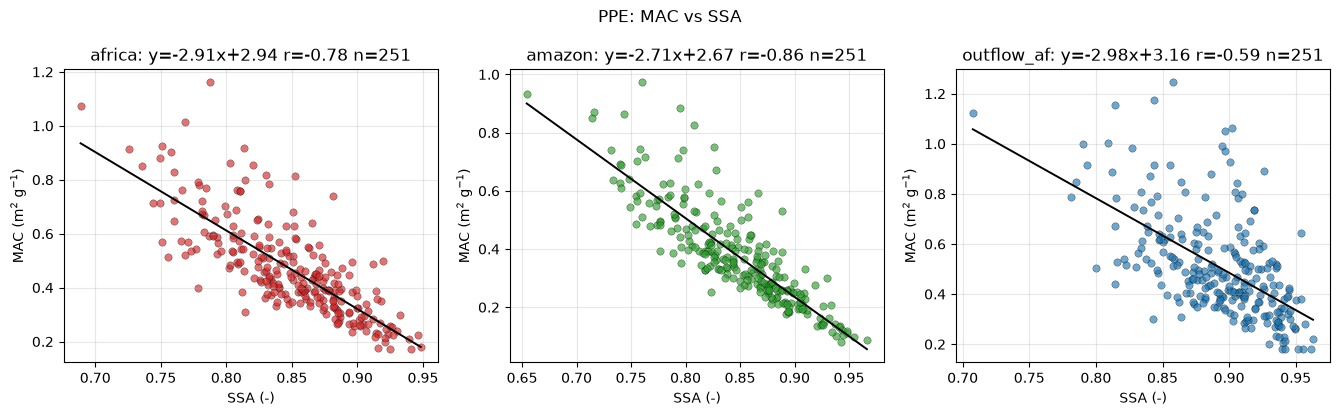

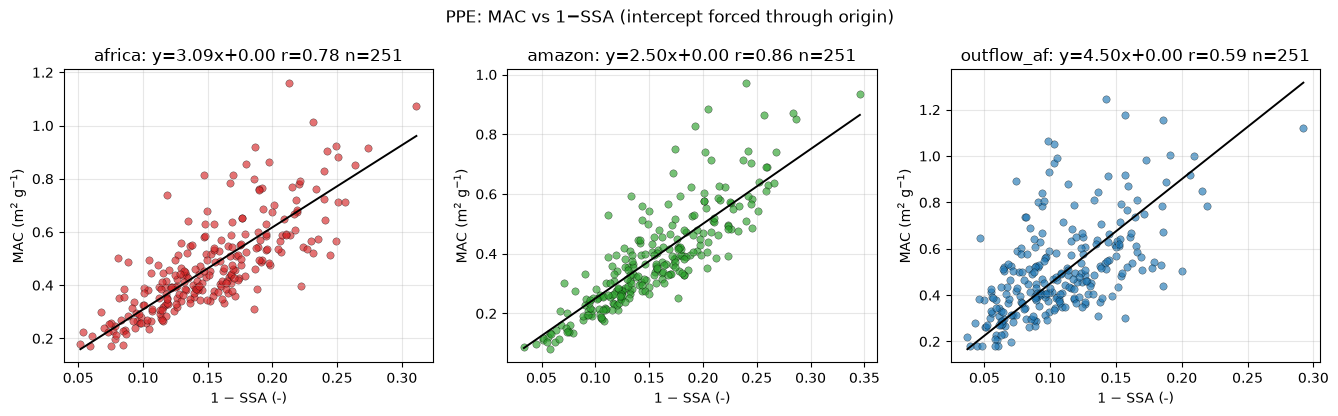

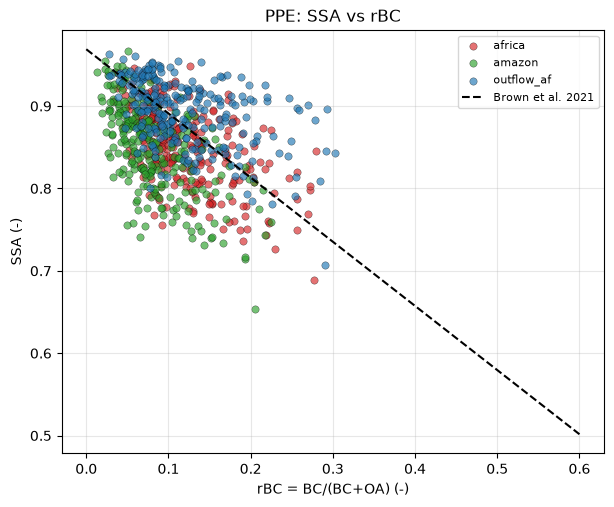

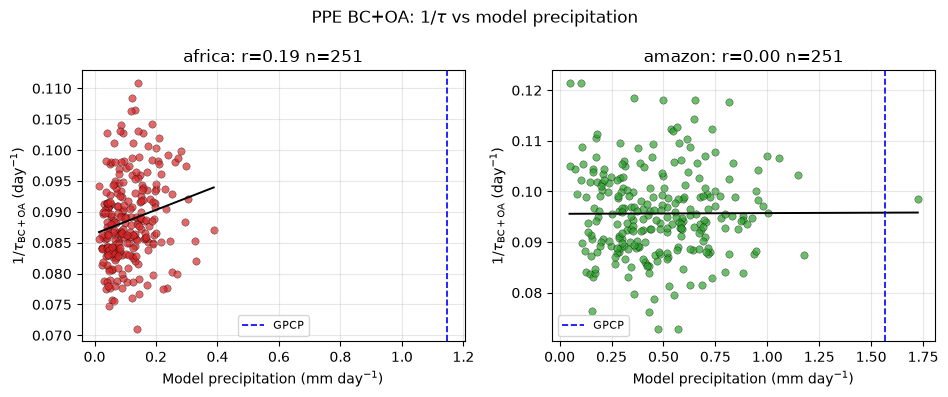

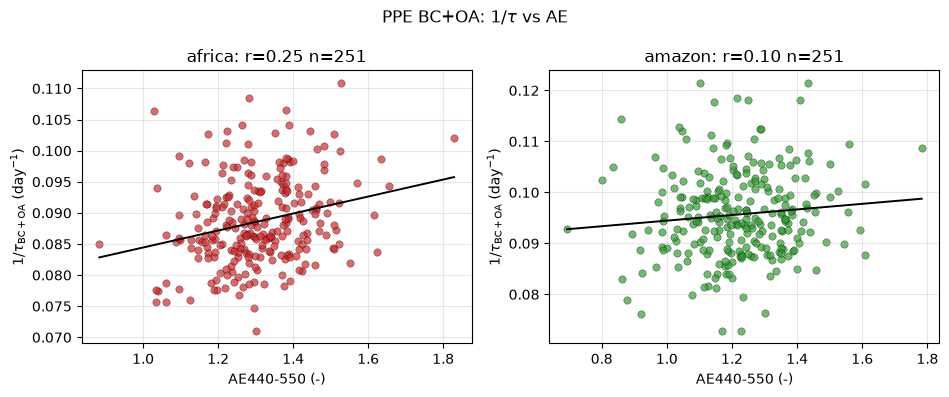

Valid AE / precip / 1/$\tau_{\mathrm{BC+OA}}$ (day$^{-1}$) rows: 502


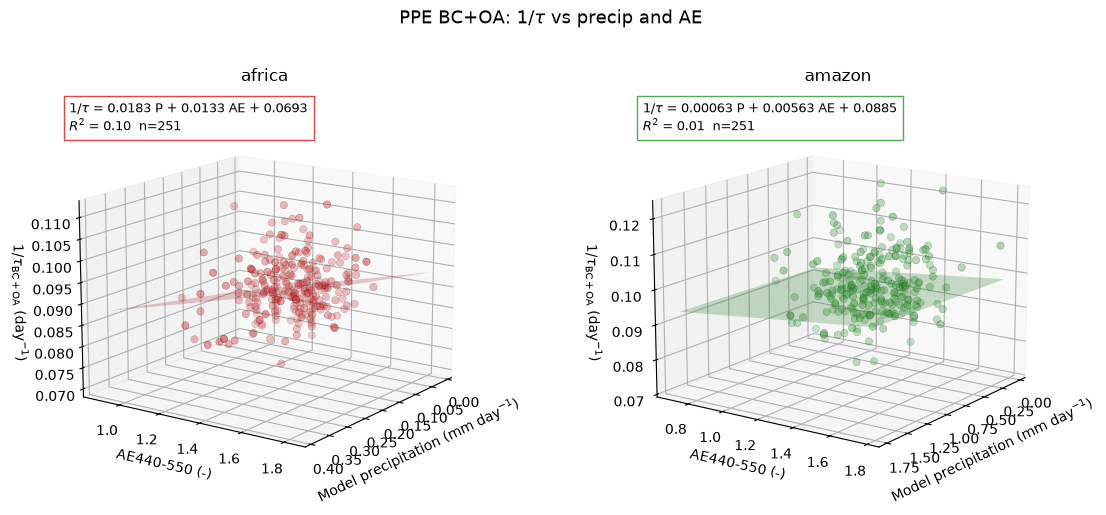

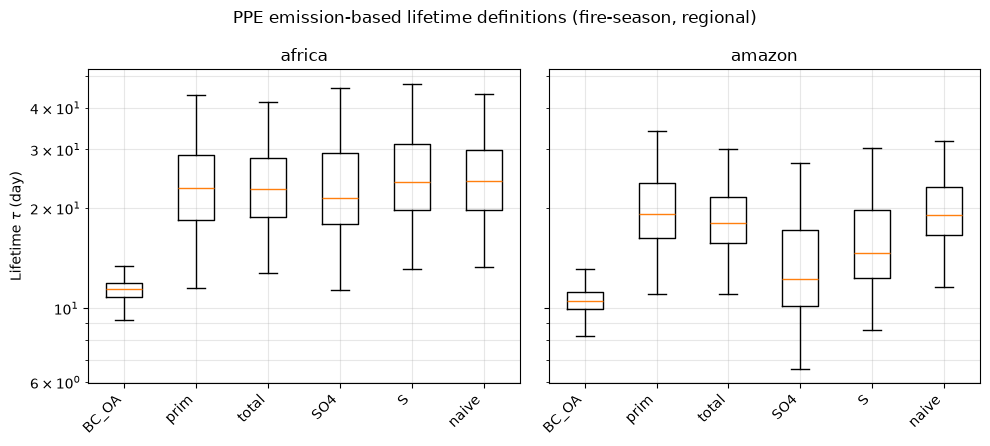

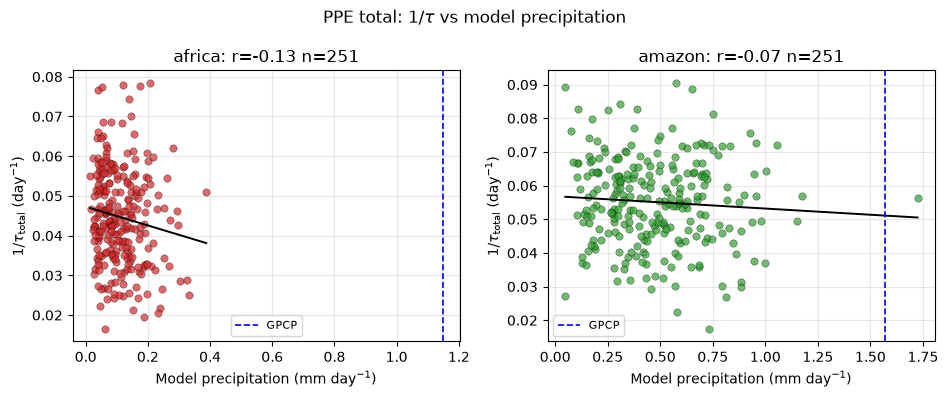

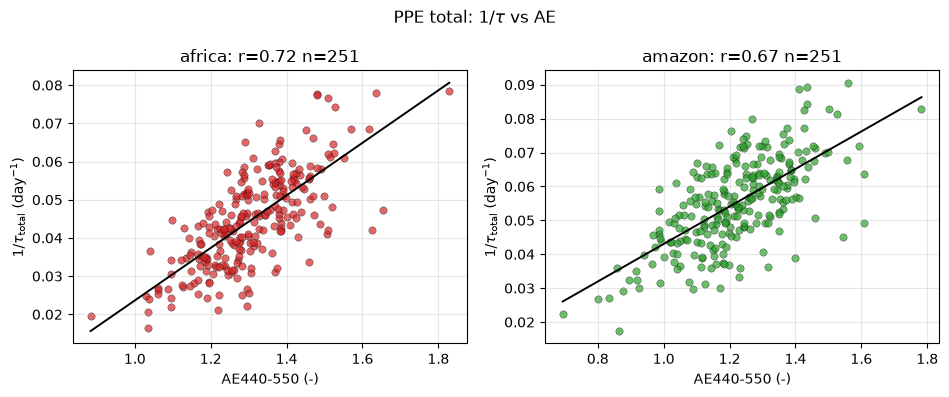

Valid AE / precip / 1/$\tau_{\mathrm{total}}$ (day$^{-1}$) rows: 502


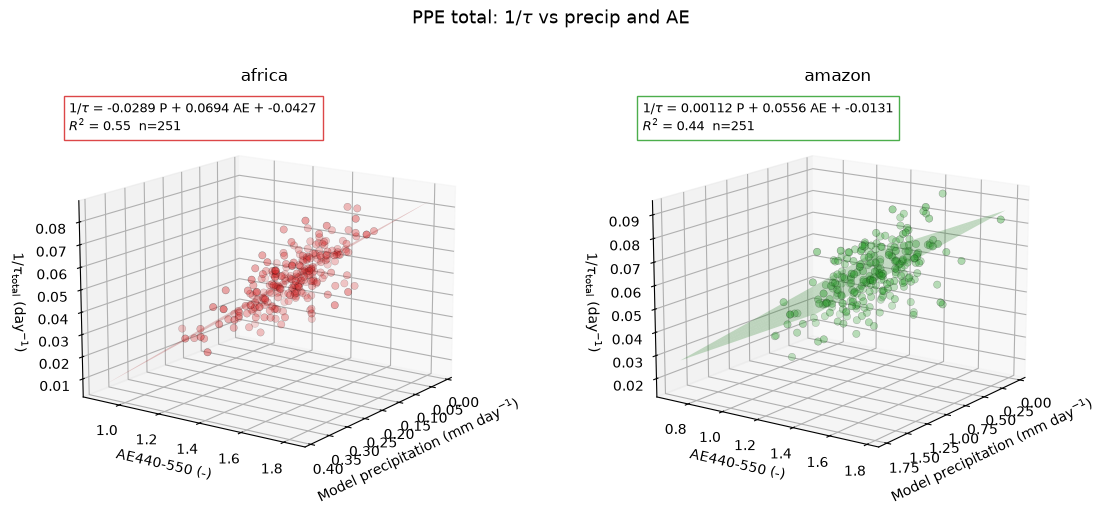

,region,model,AE,model_precip,lifetime,z
0,africa,1,1.459525,0.141808,29.747026,0.033617
1,africa,10,1.352636,0.158863,16.894281,0.059192
2,africa,100,1.097456,0.035227,22.326884,0.044789
3,africa,101,1.462386,0.199847,16.997405,0.058833
4,africa,102,1.216752,0.030797,23.636476,0.042307
...,...,...,...,...,...,...
497,amazon,96,1.241685,0.360262,13.900522,0.071940
498,amazon,97,1.303396,0.194940,15.647710,0.063907
499,amazon,98,0.916037,0.328356,28.405570,0.035204
500,amazon,99,1.279838,0.462911,20.334840,0.049177


In [30]:

plot_mac_vs_x(
    model_seasonal_df, x_col="SSA", force_intercept_zero=False,
    filename="ppe_MAC_vs_SSA.png",
    title="PPE: MAC vs SSA",
)
plot_mac_vs_x(
    model_seasonal_df, x_col="1-SSA", force_intercept_zero=INTERCEPT_0,
    filename="ppe_MAC_vs_1SSA.png",
    title="PPE: MAC vs 1−SSA (intercept forced through origin)"
    if INTERCEPT_0 else "PPE: MAC vs 1−SSA",
)
plot_ssa_vs_rbc(model_seasonal_df)

plot_tau_vs_x(
    model_seasonal_df, "lifetime_BC_OA", "precip",
    filename="ppe_inv_lifetime_bcoa_vs_precip.png",
    title=r"PPE BC+OA: 1/$\tau$ vs model precipitation",
)
plot_tau_vs_x(
    model_seasonal_df, "lifetime_BC_OA", "AE",
    filename="ppe_inv_lifetime_bcoa_vs_AE.png",
    title=r"PPE BC+OA: 1/$\tau$ vs AE",
)
plot_lifetime_ae_precip_3d(
    model_seasonal_df,
    lifetime_col="lifetime_BC_OA",
    angle=35, elev=15, inverse=True,
    filename="ppe_3d_inv_lifetime_bcoa_vs_precip_AE.png",
    title=r"PPE BC+OA: 1/$\tau$ vs precip and AE",
)

plot_lifetime_definitions(model_seasonal_df)

# Total aerosol (SO4 source from SO2+DMS+primary SO4), separate from BC+OA
plot_tau_vs_x(
    model_seasonal_df, "lifetime", "precip",
    filename="ppe_inv_lifetime_total_vs_precip.png",
    title=r"PPE total: 1/$\tau$ vs model precipitation",
)
plot_tau_vs_x(
    model_seasonal_df, "lifetime", "AE",
    filename="ppe_inv_lifetime_total_vs_AE.png",
    title=r"PPE total: 1/$\tau$ vs AE",
)
plot_lifetime_ae_precip_3d(
    model_seasonal_df,
    lifetime_col="lifetime",
    angle=35, elev=15, inverse=True,
    filename="ppe_3d_inv_lifetime_total_vs_precip_AE.png",
    title=r"PPE total: 1/$\tau$ vs precip and AE",
)


# SPEXone load 


--- SPEXone ---
Loading 12 SPEXone monthly files ...
SPEXone rows: 567,701  valid AOD+AAOD+SSA: 567,659
/home/jzhang1/.local/share/cartopy


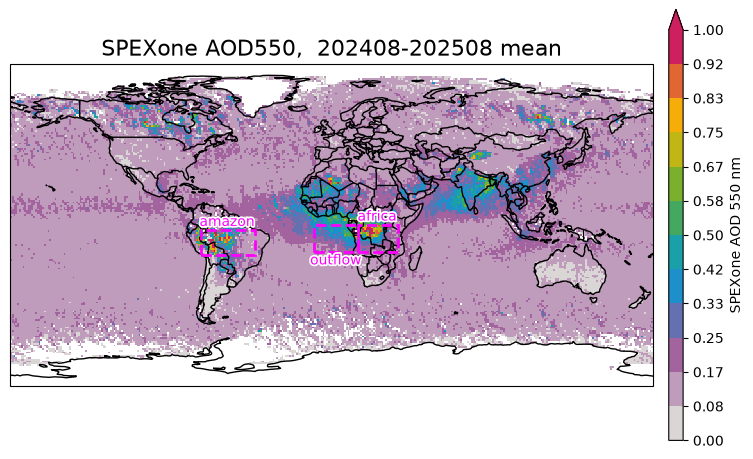

  africa: n=1926  AAOD=0.03418  SSA=0.9215
  amazon: n=1776  AAOD=0.01457  SSA=0.9412
  outflow_af: n=1709  AAOD=0.03988  SSA=0.9172


In [38]:
def load_spexone() -> pd.DataFrame:
    files = []
    for year, month in SPEXONE_YEARS_MONTHS:
        path = Path(SPEXONE_GLOB.format(year=year, month=month))
        if path.is_file():
            files.append(path)
        else:
            print(f"  SPEXone missing: {path.name}")
            ISSUES.append(f"Missing SPEXone file: {path.name}")
    if not files:
        raise FileNotFoundError("No SPEXone monthly parquet files found for PPE overlap.")
    print(f"Loading {len(files)} SPEXone monthly files ...")
    dfs = [pd.read_parquet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.tz_localize(None)
    df["month"] = df["date"].dt.to_period("M")
    df["lon360"] = (df["lon_bin"].astype(float) + 360.0) % 360.0
    df["latitude"] = df["lat_bin"].astype(float)
    aod_col = f"aod_{WVL}"
    aaod_col = f"aaod_{WVL}"
    ssa_col = f"ssa_{WVL}"
    df["AOD_550"] = df[aod_col] if aod_col in df.columns else np.nan
    df["AAOD_550"] = df[aaod_col] if aaod_col in df.columns else np.nan
    if ssa_col in df.columns:
        df["SSA"] = df[ssa_col]
    else:
        with np.errstate(divide="ignore", invalid="ignore"):
            df["SSA"] = 1.0 - df["AAOD_550"] / df["AOD_550"]
    if df["AAOD_550"].isna().all() and ssa_col in df.columns:
        df["AAOD_550"] = (1.0 - df[ssa_col]) * df["AOD_550"]
    with np.errstate(divide="ignore", invalid="ignore"):
        # SPEXone has no usable 865 nm AOD; use 440/550 like the PPE.
        if "aod_440nm" in df.columns:
            df["AE"] = -np.log(df["AOD_550"] / df["aod_440nm"]) / np.log(550.0 / 440.0)
        else:
            df["AE"] = np.nan
    df = df.replace([np.inf, -np.inf], np.nan)
    aod_f, aaod_f, ssa_f = apply_aerosol_quality_filter(
        aod=df["AOD_550"], aaod=df["AAOD_550"], ssa=df["SSA"], **QUALITY_FILTER_PARAMS
    )
    df["AOD_550"] = aod_f
    df["AAOD_550"] = aaod_f
    df["SSA"] = ssa_f
    print(
        f"SPEXone rows: {len(df):,}  valid AOD+AAOD+SSA: "
        f"{df[['AOD_550','AAOD_550','SSA']].notna().all(axis=1).sum():,}"
    )
    return df


def spexone_in_region(df: pd.DataFrame, region_name: str) -> pd.DataFrame:
    cfg = REGIONS[region_name]
    lon0, lon1 = cfg["lon_range"]
    lat0, lat1 = cfg["lat_range"]
    work = df.copy()
    if lon0 <= lon1:
        lon_ok = (work["lon360"] >= lon0) & (work["lon360"] <= lon1)
    else:
        lon_ok = (work["lon360"] >= lon0) | (work["lon360"] <= lon1)
    work = work[lon_ok & (work["latitude"] >= lat0) & (work["latitude"] <= lat1)].copy()
    months = set(cfg["season_months"])
    work = work[work["date"].dt.month.isin(months)].copy()
    # Restrict to PPE archive window
    t0, t1 = PPE_TIME
    work = work[(work["date"] >= pd.Timestamp(t0)) & (work["date"] <= pd.Timestamp(t1))].copy()
    return work


def spexone_weighted_mean(sub: pd.DataFrame, col: str) -> float:
    sub = sub.dropna(subset=[col, "latitude"])
    if sub.empty:
        return np.nan
    w = np.cos(np.deg2rad(sub["latitude"].to_numpy(dtype=float)))
    vals = sub[col].to_numpy(dtype=float)
    finite = np.isfinite(vals) & np.isfinite(w) & (w > 0)
    if finite.sum() < 3:
        return np.nan
    return float(np.average(vals[finite], weights=w[finite]))


print("\n--- SPEXone ---")
try:
    spex_df = load_spexone()
except Exception as e:
    print(f"SPEXone load failed: {e}")
    ISSUES.append(f"SPEXone load failed: {e}")
    spex_df = pd.DataFrame()



def plot_region_map(spex: pd.DataFrame, filename="ppe_aaod_region_map.png", save_fig=None):
    """Study-region map in the AOD_error_attribution style (ct.fake_uba_map),
    with fire-season mean SPEXone AOD550 on its 1° grid as background."""
    if spex.empty:
        print("Skip region map: no SPEXone data")
        return
    sub = spex.loc[: , ["lat_bin", "lon_bin", "AOD_550"]] # spex["date"].dt.month.isin(MAP_MONTHS)
    grid = sub.pivot_table(index="lat_bin", columns="lon_bin", values="AOD_550", aggfunc="mean")
    grid = grid.reindex(index=np.arange(-89.5, 90.0, 1.0), columns=np.arange(-179.5, 180.0, 1.0))

    def _lon180(x):
        return x - 360.0 if x > 180.0 else x

    # SPEXone lon is -180..180, so draw boxes in the same convention.
    # Short labels: outflow_af and africa boxes touch, so long names overlap.
    display = {"outflow_af": "outflow"}
    region_boxes = {
        display.get(name, name): (_lon180(cfg["lon_range"][0]), _lon180(cfg["lon_range"][1]),
                                  cfg["lat_range"][0], cfg["lat_range"][1])
        for name, cfg in REGIONS.items()
    }
    fig_map = ct.fake_uba_map(
        lon=grid.columns.to_numpy(),
        lat=grid.index.to_numpy(),
        c_array=grid.to_numpy(),
        zmin=0.0,
        zmax=1.0,
        labels="SPEXone AOD 550 nm",
        title="SPEXone AOD550,  202408-202508 mean",
        region_boxes=region_boxes,
        show_region_labels=False,
        region_edgecolor="magenta",
        region_linewidth=2.0,
        cbar_orientation="vertical",
        cbar_extend="max",
        show=False,
    )
    _label_region_boxes(fig_map, region_boxes)
    finish_fig(fig_map, filename, save_fig=save_fig)
plot_region_map(spex_df)

spex_obs = {}
spex_coverage_rows = []
if not spex_df.empty:
    for region in ANALYSIS_REGIONS:
        sub = spexone_in_region(spex_df, region)
        spex_obs[region] = {
            "AOD_550": spexone_weighted_mean(sub, "AOD_550"),
            "AAOD_550": spexone_weighted_mean(sub, "AAOD_550"),
            "SSA": spexone_weighted_mean(sub, "SSA"),
            "AE": spexone_weighted_mean(sub, "AE"),
            "n": int(len(sub)),
        }
        print(
            f"  {region}: n={spex_obs[region]['n']}  "
            f"AAOD={spex_obs[region]['AAOD_550']:.5f}  "
            f"SSA={spex_obs[region]['SSA']:.4f}"
        )
        if spex_obs[region]["n"] == 0:
            ISSUES.append(f"SPEXone: zero rows in {region} after season/quality filter.")
        for mon in REGIONS[region]["season_months"]:
            n_mon = int((sub["date"].dt.month == mon).sum()) if not sub.empty else 0
            spex_coverage_rows.append({"region": region, "month": mon, "n": n_mon})
            if n_mon == 0:
                ISSUES.append(
                    f"SPEXone coverage: {region} month={mon} has 0 rows "
                    "(fire season split across PPE year boundary)."
                )

# SPEXone homogenization (AAOD, SSA)

In [39]:
def sample_model_var_at_spexone(model_da, spex_sub: pd.DataFrame) -> float:
    if model_da is None or spex_sub.empty:
        return np.nan
    if isinstance(model_da, xr.Dataset):
        model_da = _get_dataarray(model_da, list(model_da.data_vars)[0])
    lat_vals = model_da.lat.values
    lon_vals = model_da.lon.values
    lat_idx = np.abs(lat_vals[:, None] - spex_sub["latitude"].values[None, :]).argmin(axis=0)
    lon_idx = np.abs(lon_vals[:, None] - spex_sub["lon360"].values[None, :]).argmin(axis=0)
    times = pd.to_datetime(model_da.time.values)
    spex_times = pd.to_datetime(spex_sub["date"].values)
    month_idx = np.array([
        np.argmin(np.abs(times - pd.Timestamp(t).to_period("M").to_timestamp()))
        for t in spex_times
    ])
    vals = np.asarray(model_da.values)[month_idx, lat_idx, lon_idx]
    weights = np.cos(np.deg2rad(spex_sub["latitude"].values.astype(float)))
    finite = np.isfinite(vals) & np.isfinite(weights)
    if finite.sum() < 3:
        return np.nan
    return float(np.average(vals[finite], weights=weights[finite]))


def _regional_dict_from_df(df, region, var_col):
    if var_col not in df.columns:
        return {}
    sub = df.loc[df["region"] == region, ["model", var_col]].dropna()
    return dict(zip(sub["model"].astype(str), sub[var_col].astype(float)))


def homogenize_spexone_variable(
    model_seasonal_df,
    spex_raw: pd.DataFrame,
    obs_col: str,
    model_var_key: str,
    var_label: str,
    data_derived_dict: dict,
):
    homogenized = {}
    rows = []
    print(f"\n--- SPEXone homogenization ({var_label}) ---")
    for region in ANALYSIS_REGIONS:
        sub = spexone_in_region(spex_raw, region)
        if sub.empty:
            print(f"  {region}: no SPEXone samples")
            continue
        obs_sampled = spexone_weighted_mean(sub, obs_col)
        regional = _regional_dict_from_df(model_seasonal_df, region, model_var_key)
        sampled = {}
        for model in regional:
            da = None
            if data_derived_dict and model in data_derived_dict:
                da = data_derived_dict[model].get(model_var_key)
            s = sample_model_var_at_spexone(da, sub)
            if np.isfinite(s) and np.isfinite(regional[model]):
                sampled[model] = s
        common = [m for m in regional if m in sampled]
        if len(common) < 3:
            print(
                f"  {region}: homogenization skipped (n={len(common)}); "
                f"raw SPEXone {var_label}={obs_sampled:.5f}"
            )
            homogenized[region] = obs_sampled
            rows.append({
                "region": region, "variable": var_label,
                "raw_mean": obs_sampled, "a": np.nan, "b": np.nan, "r2": np.nan,
                "homogenized": obs_sampled, "n_models": len(common), "skipped": True,
            })
            continue

        x = np.array([regional[m] for m in common], dtype=float)
        y = np.array([sampled[m] for m in common], dtype=float)
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        a, b = float(coeffs[0]), float(coeffs[1])
        y_pred = a * x + b
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - np.sum((y - y_pred) ** 2) / ss_tot if ss_tot > 0 else np.nan
        homogenized_regional = (obs_sampled - b) / a if a != 0 else np.nan
        homogenized[region] = homogenized_regional
        rows.append({
            "region": region, "variable": var_label,
            "raw_mean": obs_sampled, "a": a, "b": b, "r2": r2,
            "homogenized": homogenized_regional, "n_models": len(common), "skipped": False,
        })
        print(
            f"  {region}: sampled = {a:.4f}*regional + {b:.4f}  "
            f"(R^2={r2:.3f}, n={len(common)})"
        )
        print(
            f"    raw {var_label}={obs_sampled:.5f} -> homogenized={homogenized_regional:.5f}"
        )

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(x, y, s=20, alpha=0.6, edgecolors="k", linewidths=0.2)
        xs = np.linspace(np.nanmin(x), np.nanmax(x), 40)
        ax.plot(xs, a * xs + b, "r-", lw=1.5, label=f"fit R$^2$={r2:.2f}")
        ax.axvline(homogenized_regional, color="g", ls="--", label="homogenized")
        ax.axhline(obs_sampled, color="b", ls=":", label="SPEXone raw")
        ax.set_xlabel(f"PPE regional {var_label} (1)")
        ax.set_ylabel(f"PPE sampled at SPEXone {var_label} (1)")
        ax.set_title(f"{region} SPEXone homogenization ({var_label})")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        save_fig(fig, f"ppe_spexone_homog_{var_label}_{region}.png")

    return homogenized, rows


homog_rows = []
if spex_df.empty:
    print("SPEXone empty: skipping homogenization")
    ISSUES.append("SPEXone empty: homogenization skipped.")
else:
    if USE_AGG_CACHE and not data_derived:
        print("Warning: USE_AGG_CACHE without grids; homogenization may skip sampling.")
        data_derived = {}
        ISSUES.append("Homogenization ran without in-memory grids (cache path).")

    if AAOD_SPEXONE_HOMOGENIZE:
        _, rows = homogenize_spexone_variable(
            model_seasonal_df, spex_df, "AAOD_550", "abs550aer", "AAOD", data_derived
        )
        homog_rows.extend(rows)
    if SSA_SPEXONE_HOMOGENIZE:
        _, rows = homogenize_spexone_variable(
            model_seasonal_df, spex_df, "SSA", "SSA", "SSA", data_derived
        )
        homog_rows.extend(rows)

if homog_rows:
    homog_df = pd.DataFrame(homog_rows)
    homog_scratch = SCRATCH_DIR / "spexone_ppe_aaod_homogenized.csv"
    homog_path = TABLE_DIR / "spexone_ppe_aaod_homogenized.csv"
    homog_df.to_csv(homog_scratch, index=False)
    homog_df.to_csv(homog_path, index=False)
    print(f"Wrote {homog_path}")
    print(homog_df)

if spex_coverage_rows:
    cov = pd.DataFrame(spex_coverage_rows)
    cov.to_csv(TABLE_DIR / "spexone_region_month_coverage.csv", index=False)



--- SPEXone homogenization (AAOD) ---
  africa: homogenization skipped (n=0); raw SPEXone AAOD=0.03418
  amazon: homogenization skipped (n=0); raw SPEXone AAOD=0.01457
  outflow_af: homogenization skipped (n=0); raw SPEXone AAOD=0.03988

--- SPEXone homogenization (SSA) ---
  africa: homogenization skipped (n=0); raw SPEXone SSA=0.92152
  amazon: homogenization skipped (n=0); raw SPEXone SSA=0.94121
  outflow_af: homogenization skipped (n=0); raw SPEXone SSA=0.91717
Wrote /gpfs/home4/jzhang1/AeroCom_Error/Data/PPE_AAOD/spexone_ppe_aaod_homogenized.csv
       region variable  raw_mean   a   b  r2  homogenized  n_models  skipped
0      africa     AAOD  0.034182 NaN NaN NaN     0.034182         0     True
1      amazon     AAOD  0.014566 NaN NaN NaN     0.014566         0     True
2  outflow_af     AAOD  0.039875 NaN NaN NaN     0.039875         0     True
3      africa      SSA  0.921522 NaN NaN NaN     0.921522         0     True
4      amazon      SSA  0.941209 NaN NaN NaN     0.94120

# AeroCom AP3 (2010) regional seasonal table for overlay

In [41]:
# Shared cache used by AAOD_error_attribution.ipynb (py/build_regional_aggregates.py,
# built on another HPC from the full AP3 archive; AeroCom year 2010).
AEROCOM_AGG_PARQUET = project_root / "tables" / "regional_seasonal_aggregates.parquet"
AEROCOM_EXCLUDE_MODELS = [  # same list as AAOD_error_attribution.ipynb
    "GEOS-i33p2-met2010_AP3-CTRL-2010",
    "GISS-ModelE2p1p1-OMA_AP3-CTRL-2010",
    "GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010",
    "GISS-ModelE2p1p1-MATRIX_AP3-CTRL",
    "NorESM2-met2010_AP3-CTRL-v3",
]
# Notebook default: load/deposition BC+OA lifetime, filtered to 0.3-50 d.
AEROCOM_LIFETIME_VAR = "lifetime_BC_OA"
AEROCOM_COLOR = "black"


def load_aerocom_seasonal() -> Tuple[pd.DataFrame, Dict[str, float]]:
    if not AEROCOM_AGG_PARQUET.is_file():
        print(f"AeroCom table missing: {AEROCOM_AGG_PARQUET}")
        ISSUES.append(f"AeroCom overlay skipped: {AEROCOM_AGG_PARQUET.name} not built.")
        return pd.DataFrame(), {}
    long = pd.read_parquet(AEROCOM_AGG_PARQUET)
    long = long[long["region"].isin(ANALYSIS_REGIONS)]
    gpcp_2010 = {
        r["region"]: float(r["value"])
        for _, r in long[(long["dataset"] == "GPCP") & (long["var"] == "precip")].iterrows()
    }
    mod = long[
        ~long["dataset"].isin(["POLDER", "GPCP"] + AEROCOM_EXCLUDE_MODELS)
        & long["source"].isin(["aggregated", "derived"])
    ]
    wide = (
        mod.pivot_table(index=["region", "dataset"], columns="var", values="value", aggfunc="first")
        .reset_index()
        .rename(columns={"dataset": "model"})
    )
    wide.columns.name = None
    # The cache AE is per-cell 550/870; rebuild AE440-550 from the regional-mean
    # AODs to match PPE/SPEXone (NaN where od440aer is absent).
    wide["AE_550_870"] = wide.get("AE")
    with np.errstate(divide="ignore", invalid="ignore"):
        wide["AE"] = -np.log(wide["od550aer"] / wide["od440aer"]) / np.log(550.0 / 440.0)
        wide["rBC"] = wide["loadbc"] / (wide["loadbc"] + wide["loadoa"])
    wide["lifetime_BC_OA"] = wide.get(AEROCOM_LIFETIME_VAR, np.nan)
    lt_emi = wide.get("lifetime_BC_OA_emission", pd.Series(np.nan, index=wide.index))
    wide["lifetime_BC_OA_emission"] = lt_emi.where((lt_emi >= 0.3) & (lt_emi <= 50.0))
    no_lt = ~wide["region"].isin(LIFETIME_REGIONS)
    wide.loc[no_lt, ["lifetime_BC_OA", "lifetime_BC_OA_emission"]] = np.nan
    print(f"AeroCom models: {wide['model'].nunique()}  "
          f"(AE440-550 available: {wide.loc[wide['AE'].notna(), 'model'].nunique()})")
    return wide, gpcp_2010


print("\n--- AeroCom overlay table ---")
aerocom_df, aerocom_gpcp_2010 = load_aerocom_seasonal()
if not aerocom_df.empty:
    aerocom_df.to_csv(TABLE_DIR / "aerocom_seasonal_wide_africa_amazon_outflow.csv", index=False)
    n_ae = aerocom_df.loc[aerocom_df["AE"].notna(), "model"].nunique()
    if n_ae < aerocom_df["model"].nunique():
        ISSUES.append(
            f"AeroCom AE440-550 only for {n_ae}/{aerocom_df['model'].nunique()} models "
            "(od440aer missing for the rest); they drop out of AE plots."
        )
    ISSUES.append(
        "AeroCom overlay uses tables/regional_seasonal_aggregates.parquet (year 2010, other HPC) "
        "vs PPE Aug 2024-Jul 2025. AeroCom AE440-550 and rBC come from regional-mean "
        "od440/od550 and loadbc/loadoa (PPE: per-cell then averaged). AeroCom lifetime_BC_OA "
        "is load/deposition (notebook default, 0.3-50 d filter); PPE is load/emission only, "
        "so lifetime_BC_OA_emission is also overlaid for a like-for-like comparison."
    )


--- AeroCom overlay table ---
AeroCom models: 26  (AE440-550 available: 23)


# Precipitation: PPE (2024-25) and AeroCom (2010) vs GPCP (Data/Prec)

In [42]:
PPE_MONTH_ORDER = [f"{y}-{m:02d}" for y, m in SPEXONE_YEARS_MONTHS]


def plot_precip_seasonal_cycle(filename="precip_ppe_vs_gpcp_monthly.png"):
    if model_monthly_df.empty or "precip" not in model_monthly_df.columns or not gpcp_rows:
        print("Skip precip seasonal cycle: missing monthly PPE precip or GPCP")
        return
    work = model_monthly_df[["region", "model", "month", "precip"]].copy()
    work["month"] = work["month"].astype(str)
    gpcp_m = pd.DataFrame(gpcp_rows)
    x = np.arange(len(PPE_MONTH_ORDER))
    fig, axes = plt.subplots(1, len(PLOT_REGIONS), figsize=(5.2 * len(PLOT_REGIONS), 4.2),
                             squeeze=False, sharey=False)
    for ax, region in zip(axes.ravel(), PLOT_REGIONS):
        color = REGION_COLORS.get(region, "#333333")
        q = (work[work["region"] == region].groupby("month")["precip"]
             .quantile([0.05, 0.5, 0.95]).unstack().reindex(PPE_MONTH_ORDER))
        ax.fill_between(x, q[0.05], q[0.95], color=color, alpha=0.25, label="PPE 5–95%")
        ax.plot(x, q[0.5], color=color, lw=2, label="PPE median")
        g = gpcp_m[gpcp_m["region"] == region].set_index("month").reindex(PPE_MONTH_ORDER)
        filled = g["source_month"].astype(str) != g.index.to_series().astype(str)
        ax.plot(x, g["precip_obs"], "k-o", ms=4, lw=1.5, label="GPCP")
        if filled.any():
            ax.plot(x[filled.to_numpy()], g.loc[filled, "precip_obs"], "o", mfc="white",
                    mec="k", ms=7, label="GPCP (Jul 2024 fill)")
        for i, mon in enumerate(PPE_MONTH_ORDER):
            if int(mon[-2:]) in REGIONS[region]["season_months"]:
                ax.axvspan(i - 0.5, i + 0.5, color="gold", alpha=0.12, lw=0)
        ax.set_xticks(x)
        ax.set_xticklabels([pd.Timestamp(m).strftime("%b\n%y") for m in PPE_MONTH_ORDER],
                           fontsize=7)
        ax.set_ylabel(r"Precipitation (mm day$^{-1}$)")
        ax.set_title(f"{region} (shaded: fire season)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc="upper left")
    fig.suptitle("Regional monthly precipitation: PPE vs GPCP (Aug 2024 – Jul 2025)")
    fig.tight_layout()
    save_fig(fig, filename)


def plot_precip_season_box(filename="precip_ppe_aerocom_vs_gpcp_season.png"):
    fig, axes = plt.subplots(1, len(PLOT_REGIONS), figsize=(4.4 * len(PLOT_REGIONS), 4.4),
                             squeeze=False)
    for ax, region in zip(axes.ravel(), PLOT_REGIONS):
        color = REGION_COLORS.get(region, "#333333")
        ppe = model_seasonal_df.loc[model_seasonal_df["region"] == region, "precip"].dropna()
        aer = (aerocom_df.loc[aerocom_df["region"] == region, "precip"].dropna()
               if not aerocom_df.empty and "precip" in aerocom_df else pd.Series(dtype=float))
        data, labels = [], []
        for vals, lab in ((ppe, f"PPE\n2024-25\n(n={len(ppe)})"),
                          (aer, f"AeroCom\n2010\n(n={len(aer)})")):
            if len(vals):
                data.append(vals.to_numpy())
                labels.append(lab)
        if not data:
            ax.set_title(f"{region}: no data")
            continue
        bp = ax.boxplot(data, widths=0.5, showfliers=False, patch_artist=True)
        for patch, fc in zip(bp["boxes"], [color, "white"]):
            patch.set_facecolor(fc)
            patch.set_alpha(0.5 if fc != "white" else 1.0)
        rng = np.random.default_rng(0)
        for i, vals in enumerate(data, start=1):
            ax.scatter(i + rng.uniform(-0.12, 0.12, len(vals)), vals, s=8, alpha=0.4,
                       color=color if i == 1 else AEROCOM_COLOR, zorder=3)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontsize=8)
        obs_now = gpcp_obs.get(region, np.nan)
        obs_2010 = aerocom_gpcp_2010.get(region, np.nan)
        if np.isfinite(obs_now):
            ax.axhline(obs_now, color="b", ls="--", lw=1.3, label=f"GPCP 2024-25 ({obs_now:.2f})")
        if np.isfinite(obs_2010):
            ax.axhline(obs_2010, color="gray", ls=":", lw=1.5, label=f"GPCP 2010 ({obs_2010:.2f})")
        ax.set_ylabel(r"Fire-season precipitation (mm day$^{-1}$)")
        ax.set_title(f"{region} (months {list(REGIONS[region]['season_months'])})", fontsize=10)
        ax.grid(True, alpha=0.3, axis="y")
        ax.legend(fontsize=7, loc="upper right")
    fig.suptitle("Fire-season regional precipitation vs GPCP")
    fig.tight_layout()
    save_fig(fig, filename)


def plot_precip_maps(months=MAP_MONTHS):
    """GPCP Jun–Oct mean and PPE ensemble-mean minus GPCP on the PPE grid."""
    if gpcp_da is None or not data_derived:
        print("Skip precip maps: GPCP or gridded PPE precip unavailable (cache path)")
        return
    fields = []
    for m in target_models:
        da = _get_dataarray(data_derived[m].get("precip"), "precip")
        if da is None:
            continue
        fields.append(da.sel(time=da.time.dt.month.isin(months)).mean("time"))
    if not fields:
        return
    ppe_mean = xr.concat(fields, dim="member").mean("member")
    gpcp_mean = gpcp_da.sel(time=gpcp_da.time.dt.month.isin(months)).mean("time")
    # Periodic pad: GPCP lon starts at 0.25, PPE grid has lon=0.
    gpcp_wrap = xr.concat(
        [gpcp_mean.assign_coords(lon=gpcp_mean.lon - 360.0), gpcp_mean,
         gpcp_mean.assign_coords(lon=gpcp_mean.lon + 360.0)], dim="lon",
    )
    gpcp_on_ppe = gpcp_wrap.interp(lat=ppe_mean.lat, lon=ppe_mean.lon, method="linear")
    diff = ppe_mean - gpcp_on_ppe

    def _to180(da):
        da = da.assign_coords(lon=((da.lon + 180.0) % 360.0) - 180.0).sortby("lon")
        return da.sortby("lat")

    display = {"outflow_af": "outflow"}
    boxes = {
        display.get(n, n): ((c["lon_range"][0] + 180) % 360 - 180,
                            (c["lon_range"][1] + 180) % 360 - 180,
                            c["lat_range"][0], c["lat_range"][1])
        for n, c in REGIONS.items()
    }
    common = dict(region_boxes=boxes, show_region_labels=False, region_edgecolor="magenta",
                  region_linewidth=2.0, cbar_orientation="vertical", show=False)
    g = _to180(gpcp_mean)
    fig = ct.fake_uba_map(
        lon=g.lon.values, lat=g.lat.values, c_array=g.values, zmin=0.0, zmax=12.0,
        labels=r"GPCP precipitation (mm day$^{-1}$)",
        title="GPCP precipitation, Jun–Oct 2024-25 mean", cbar_extend="max", **common,
    )
    _label_region_boxes(fig, boxes)
    save_fig(fig, "precip_gpcp_map.png")
    d = _to180(diff)
    fig = ct.fake_uba_map(
        lon=d.lon.values, lat=d.lat.values, c_array=d.values, zmin=-6.0, zmax=6.0,
        mycolor="diff", labels=r"PPE mean − GPCP (mm day$^{-1}$)",
        title=f"PPE ensemble mean ({len(fields)} members) − GPCP, Jun–Oct", cbar_extend="both",
        **common,
    )
    _label_region_boxes(fig, boxes)
    save_fig(fig, "precip_ppe_minus_gpcp_map.png")


print("\n--- Precipitation comparison vs GPCP ---")
if not model_seasonal_df.empty:
    plot_precip_seasonal_cycle()
    plot_precip_season_box()
    plot_precip_maps()



--- Precipitation comparison vs GPCP ---
  Saved /gpfs/home4/jzhang1/AeroCom_Error/figure/PPE_AAOD/precip_ppe_vs_gpcp_monthly.png
  Saved /gpfs/home4/jzhang1/AeroCom_Error/figure/PPE_AAOD/precip_ppe_aerocom_vs_gpcp_season.png
Skip precip maps: GPCP or gridded PPE precip unavailable (cache path)


# Combined PPE + AeroCom figures (PPE members unlabeled; one legend entry each)

In [ ]:
def _spex_value(region: str, var: str) -> float:
    """Homogenized SPEXone value for source regions, else raw sampled mean."""
    for r in homog_rows:
        if r["region"] == region and r["variable"] == var and not r["skipped"]:
            return float(r["homogenized"])
    key = {"AAOD": "AAOD_550"}.get(var, var)
    return float(spex_obs.get(region, {}).get(key, np.nan))


def _fit_line(ax, x, y, color, ls, through_origin=False):
    if len(x) < 3:
        return np.nan
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 40)
    if through_origin:
        F = np.sum(x * y) / np.sum(x ** 2)
        ax.plot(xs, F * xs, color=color, ls=ls, lw=1.6)
        return 1 - np.sum((y - F * x) ** 2) / np.sum(y ** 2)
    lr = linregress(x, y)
    ax.plot(xs, lr.slope * xs + lr.intercept, color=color, ls=ls, lw=1.6)
    return lr.rvalue ** 2


def _xy(df, region, xcol, ycol, inverse_y=False):
    if df.empty or xcol not in df.columns or ycol not in df.columns:
        return np.array([]), np.array([])
    sub = df.loc[df["region"] == region, [xcol, ycol]].replace([np.inf, -np.inf], np.nan).dropna()
    if inverse_y:
        sub = sub.loc[sub[ycol] > 0]
    x = sub[xcol].to_numpy(dtype=float)
    y = sub[ycol].to_numpy(dtype=float)
    return x, (1.0 / y if inverse_y else y)


def plot_combined(xcol, ycol, regions, filename, title, inverse_y=False,
                  through_origin=False, obs_x=None, obs_y=None, ylabel=None,
                  brown_line=False, aer_ycol=None, aer_obs_x=None):
    ppe = model_seasonal_df.copy()
    aer = aerocom_df.copy()
    for d in (ppe, aer):
        if not d.empty and "SSA" in d.columns:
            d["1-SSA"] = 1.0 - d["SSA"]
    fig, axes = plt.subplots(1, len(regions), figsize=(5 * len(regions), 4.4), squeeze=False)
    for ax, region in zip(axes.ravel(), regions):
        color = REGION_COLORS.get(region, "#333333")
        xp, yp = _xy(ppe, region, xcol, ycol, inverse_y)
        xa, ya = _xy(aer, region, xcol, aer_ycol or ycol, inverse_y)
        ax.scatter(xp, yp, s=16, alpha=0.45, color=color, edgecolors="none",
                   label=f"PPE ({len(xp)} members)")
        r2p = _fit_line(ax, xp, yp, color, "-", through_origin)
        ax.scatter(xa, ya, s=55, marker="D", facecolors="white", edgecolors=AEROCOM_COLOR,
                   linewidths=1.2, label=f"AeroCom AP3 ({len(xa)} models)", zorder=4)
        r2a = _fit_line(ax, xa, ya, AEROCOM_COLOR, "--", through_origin)
        if brown_line:
            xs = np.linspace(0, 1, 50)
            ax.plot(xs, BROWN_SSA_INTERCEPT + BROWN_SSA_SLOPE * xs, color="gray", ls=":",
                    lw=1.4, label="Brown et al.")
        ox = obs_x(region) if callable(obs_x) else None
        oy = obs_y(region) if callable(obs_y) else None
        if ox is not None:
            ox_val, ox_label = ox if isinstance(ox, tuple) else (ox, "obs")
            if np.isfinite(ox_val):
                ax.axvline(ox_val, color="b", ls="--", lw=1.1, label=ox_label)
        oxa = aer_obs_x(region) if callable(aer_obs_x) else None
        if oxa is not None and np.isfinite(oxa[0]):
            ax.axvline(oxa[0], color="gray", ls="--", lw=1.1, label=oxa[1])
        if oy is not None and np.isfinite(oy):
            ax.axhline(oy, color="b", ls=":", lw=1.1, label="SPEXone")
        ax.set_title(f"{region}\nR²: PPE={r2p:.2f}, AeroCom={r2a:.2f}", fontsize=10)
        ax.set_xlabel(_axis_label(xcol))
        ax.set_ylabel(ylabel or _axis_label(ycol))
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc="best")
    fig.suptitle(title)
    fig.tight_layout()
    save_fig(fig, filename)


def _obs_x_gpcp(region):
    v = gpcp_obs.get(region, np.nan)
    return (v, "GPCP 2024-25") if np.isfinite(v) else None


def _obs_x_gpcp_2010(region):
    return (aerocom_gpcp_2010.get(region, np.nan), "GPCP 2010 (AeroCom yr)")


def plot_combined_3d(lifetime_col="lifetime_BC_OA", regions=None,
                     filename="combined_3d_inv_lifetime_bcoa_vs_precip_AE.png",
                     aer_lifetime_col=None, title=None):
    regions = regions or LIFETIME_REGIONS
    fig = plt.figure(figsize=(6.5 * len(regions), 5.5))
    for idx, region in enumerate(regions):
        ax = fig.add_subplot(1, len(regions), idx + 1, projection="3d")
        color = REGION_COLORS.get(region, "#333333")
        for df, style in ((model_seasonal_df, "ppe"), (aerocom_df, "aer")):
            col = lifetime_col if style == "ppe" else (aer_lifetime_col or lifetime_col)
            if df.empty or col not in df.columns:
                continue
            sub = df.loc[df["region"] == region, ["precip", "AE", col]]
            sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
            sub = sub.loc[sub[col] > 0]
            if sub.empty:
                continue
            x, y = sub["precip"].to_numpy(float), sub["AE"].to_numpy(float)
            z = 1.0 / sub[col].to_numpy(float)
            if style == "ppe":
                ax.scatter(x, y, z, s=14, color=color, alpha=0.45, label=f"PPE (n={len(x)})")
            else:
                ax.scatter(x, y, z, s=50, marker="D", facecolors="white",
                           edgecolors=AEROCOM_COLOR, label=f"AeroCom (n={len(x)})")
            if len(x) >= 4:
                A = np.column_stack([x, y, np.ones_like(x)])
                coef, *_ = np.linalg.lstsq(A, z, rcond=None)
                xx, yy = np.meshgrid(np.linspace(x.min(), x.max(), 10),
                                     np.linspace(y.min(), y.max(), 10))
                ax.plot_surface(xx, yy, coef[0] * xx + coef[1] * yy + coef[2], alpha=0.2,
                                color=color if style == "ppe" else "gray", linewidth=0)
        ax.set_xlabel(_axis_label("precip"))
        ax.set_ylabel(_axis_label("AE"))
        ax.set_zlabel(_axis_label(f"inv_{lifetime_col}"))
        ax.set_title(region)
        ax.view_init(elev=15, azim=35)
        ax.legend(fontsize=7, loc="upper left")
    fig.suptitle(title or r"PPE + AeroCom: 1/$\tau_{\mathrm{BC+OA}}$ vs precipitation and AE")
    fig.tight_layout()
    save_fig(fig, filename)


def plot_combined_outflow_meta(filename="combined_outflow_meta_model.png"):
    fig, ax = plt.subplots(figsize=(5.5, 5.2))
    styles = {"PPE": dict(s=16, alpha=0.5, color=REGION_COLORS[OUTFLOW_REGION]),
              "AeroCom": dict(s=55, marker="D", facecolors="white", edgecolors=AEROCOM_COLOR)}
    vals = []
    for p in outflow_params:
        meta = outflow_meta_rows[p["dataset"]]
        ax.scatter(meta["AAOD_out"], meta["AAOD_meta_fit"], **styles[p["dataset"]],
                   label=f"{p['dataset']} (R²={p['r2']:.2f}, n={p['n']})")
        vals += list(meta["AAOD_out"]) + list(meta["AAOD_meta_fit"])
    if not vals:
        plt.close(fig)
        return
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    ax.plot([lo, hi], [lo, hi], "k:", lw=1)
    if np.isfinite(spex_outflow_aaod):
        ax.axvline(spex_outflow_aaod, color="b", ls="--", lw=1.1, label="SPEXone")
    ax.set_xlabel("Model outflow AAOD$_{550}$ (1)")
    ax.set_ylabel("Meta-model outflow AAOD$_{550}$ (1)")
    ax.set_title("Outflow AAOD from African E·τ·MAC (Eq. 6)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    save_fig(fig, filename)


if not model_seasonal_df.empty:
    plot_combined(
        "1-SSA", "MAC", PLOT_REGIONS, "combined_MAC_vs_1SSA.png",
        "PPE + AeroCom: MAC vs 1−SSA" + (" (fit through origin)" if INTERCEPT_0 else ""),
        through_origin=INTERCEPT_0,
        obs_x=lambda r: (1.0 - _spex_value(r, "SSA"), "SPEXone"),
    )
    plot_combined(
        "SSA", "MAC", PLOT_REGIONS, "combined_MAC_vs_SSA.png", "PPE + AeroCom: MAC vs SSA",
        obs_x=lambda r: (_spex_value(r, "SSA"), "SPEXone"),
    )
    plot_combined(
        "rBC", "SSA", PLOT_REGIONS, "combined_SSA_vs_rBC.png", "PPE + AeroCom: SSA vs rBC",
        obs_y=lambda r: _spex_value(r, "SSA"), brown_line=True,
    )
    plot_combined(
        "SSA", "abs550aer", PLOT_REGIONS, "combined_AAOD_vs_SSA.png",
        "PPE + AeroCom: AAOD vs SSA",
        obs_x=lambda r: (_spex_value(r, "SSA"), "SPEXone"),
        obs_y=lambda r: _spex_value(r, "AAOD"),
    )
    # AeroCom lifetime: load/deposition (notebook default) and load/emission (as PPE)
    for aer_lt, tag, desc in (
        ("lifetime_BC_OA", "bcoa", "AeroCom load/deposition"),
        ("lifetime_BC_OA_emission", "bcoa_aeroemi", "AeroCom load/emission"),
    ):
        plot_combined(
            "precip", "lifetime_BC_OA", LIFETIME_REGIONS,
            f"combined_inv_lifetime_{tag}_vs_precip.png",
            rf"PPE (load/emission) + {desc}: 1/$\tau_{{\mathrm{{BC+OA}}}}$ vs precipitation",
            inverse_y=True, obs_x=_obs_x_gpcp, aer_obs_x=_obs_x_gpcp_2010,
            ylabel=_axis_label("inv_lifetime_BC_OA"), aer_ycol=aer_lt,
        )
        plot_combined(
            "AE", "lifetime_BC_OA", LIFETIME_REGIONS,
            f"combined_inv_lifetime_{tag}_vs_AE.png",
            rf"PPE (load/emission) + {desc}: 1/$\tau_{{\mathrm{{BC+OA}}}}$ vs AE440-550",
            inverse_y=True, obs_x=lambda r: (_spex_value(r, "AE"), "SPEXone"),
            ylabel=_axis_label("inv_lifetime_BC_OA"), aer_ycol=aer_lt,
        )
        plot_combined_3d(
            aer_lifetime_col=aer_lt,
            filename=f"combined_3d_inv_lifetime_{tag}_vs_precip_AE.png",
            title=rf"PPE (load/emission) + {desc}: 1/$\tau_{{\mathrm{{BC+OA}}}}$ vs precip and AE",
        )
    plot_combined_outflow_meta()